# Unified Simulation Analysis – Corrected for Accurate Validation

This notebook analyses simulation output (snapshot CSV) from your ABM, which uses the **Komi et al. 2025 ODE‑consistent model** with **temperature‑dependent adult mortality**. Parameters are loaded directly from the YAML file to ensure consistency.

**Key improvements**
- λ_max computed with **exact same temperature‑dependent adult mortality** as the simulation.
- Stage durations estimated via **cross‑correlation** (peak‑to‑peak) when possible, otherwise using theoretical values at mean temperature.
- Environmental correlation uses available climate data from snapshots.
- Suitability maps created using KDE on adult points and rasterised tank load.
- Validation against GBIF/iNaturalist occurrences (if provided).

**Assumptions**
- Ticks per day = 96 (15‑minute ticks).
- Livestock density fixed at 0.5 for λ_max (consistent with simulation’s default).


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from scipy.spatial import cKDTree
from scipy.stats import pearsonr, spearmanr
from scipy.signal import correlate, correlation_lags
from sklearn.neighbors import KernelDensity
from scipy.interpolate import RegularGridInterpolator
import rasterio
from rasterio.transform import from_origin
import os
import warnings
warnings.filterwarnings('ignore')

# ======================================================================
# CONFIGURATION – EDIT THESE PATHS
# ======================================================================
INPUT_FILE = "/home/void/Documents/codes/monadvsim/results/merged_snapshots_20260826_030006.csv"
STUDY_AREA_FILE = "/home/void/Documents/codes/monadvsim/prepared_data/somali/somali.shp"
OUTPUT_DIR = "/mnt/monadworld/projects/phd/article_manuscripts/new/figs/somali"
OCCURRENCE_FILE = "prepared_data/ethiopia_occurrence/merged_observations.csv"

# Simulation parameters
TICKS_PER_DAY = 96
CHUNKSIZE = 100000
MAX_SPATIAL_POINTS_PER_TICK = 100000
STAGE_COLORS = {'ADULT': '#2E8B57', 'LARVA': '#4169E1', 'PUPA': '#FF8C00'}

# Environment variables as in simulation (tokens)
ENV_VARS = [
    ('t2m', 'Temperature', '°C', lambda x: x, False),
    ('tp', 'Precipitation', 'mm', lambda x: x, True),
]

# Export settings
EXPORT_RASTERS = True
KDE_BANDWIDTH_DEG = 0.002
KDE_GRID_RES = 200

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ======================================================================
# LOAD STUDY AREA BASEMAP
# ======================================================================
study_area = None
if os.path.exists(STUDY_AREA_FILE):
    study_area = gpd.read_file(STUDY_AREA_FILE)
    if study_area.crs is None:
        study_area.crs = "EPSG:4326"
    elif study_area.crs.to_epsg() != 4326:
        study_area = study_area.to_crs("EPSG:4326")
    print(f"Loaded study area basemap: {STUDY_AREA_FILE}")
    print(f"Bounds: {study_area.total_bounds}")
else:
    print(f"Study area file not found: {STUDY_AREA_FILE}. Spatial plots will be without basemap.")

# ======================================================================
# LOAD OCCURRENCE DATA
# ======================================================================
occurrences = None
if OCCURRENCE_FILE and os.path.exists(OCCURRENCE_FILE):
    if OCCURRENCE_FILE.endswith('.shp') or OCCURRENCE_FILE.endswith('.geojson'):
        occurrences = gpd.read_file(OCCURRENCE_FILE).to_crs("EPSG:4326")
    else:
        occ_df = pd.read_csv(OCCURRENCE_FILE, delimiter=",")
        if 'longitude' in occ_df.columns and 'latitude' in occ_df.columns:
            occurrences = gpd.GeoDataFrame(occ_df, geometry=gpd.points_from_xy(occ_df.longitude, occ_df.latitude), crs="EPSG:4326")
        else:
            print("Occurrence CSV must contain 'longitude' and 'latitude' columns.")
    if occurrences is not None:
        original_count = len(occurrences)
        if study_area is not None:
            if occurrences.crs != study_area.crs:
                occurrences = occurrences.to_crs(study_area.crs)
            occurrences = gpd.sjoin(occurrences, study_area, how='inner', predicate='within')
            occurrences = occurrences.drop(columns='index_right')
            print(f"Clipped occurrence records from {original_count} to {len(occurrences)} (inside study area)")
        else:
            print(f"Loaded {original_count} occurrence records (no clipping – study area missing).")
else:
    print("No occurrence file provided – validation plots will be skipped.")

# ======================================================================
# DEFINE COLUMNS & DTYPES (matching simulation export)
# ======================================================================
living_base_cols = ['TickCount', 'Stage', 'X', 'Y', 'AgentID', 'Age', 'Energy', 'Gravid']
env_col_names = [v[0] for v in ENV_VARS]
living_columns = living_base_cols + env_col_names
inert_columns = ['TickCount', 'X', 'Y', 'EggCount', 'LarvaCount', 'waterVolume', 'AgentID']

living_dtypes = {
    'TickCount': 'int32',
    'Stage': 'category',
    'X': 'float32',
    'Y': 'float32',
    'AgentID': 'object',
    'Age': 'int16',
    'Energy': 'float32',
    'Gravid': 'int8'
}
for col in env_col_names:
    living_dtypes[col] = 'float32'

inert_dtypes = {
    'TickCount': 'int32',
    'X': 'float32',
    'Y': 'float32',
    'EggCount': 'int32',
    'LarvaCount': 'int32',
    'waterVolume': 'float32',
    'AgentID': 'object'
}

print(f"Environment variables: {env_col_names}")
print("Configuration ready.")

Loaded study area basemap: /home/void/Documents/codes/monadvsim/prepared_data/somali/somali.shp
Bounds: [39.09111796  3.40667    47.98824    11.09707999]
Clipped occurrence records from 72 to 30 (inside study area)
Environment variables: ['t2m', 'tp']
Configuration ready.


# 1. Memory‑Efficient Daily Aggregation

Processes the merged CSV in chunks and aggregates daily totals for populations and environmental means.

In [15]:
def incremental_aggregation(filepath, living_cols, inert_cols, living_dtypes, inert_dtypes, 
                            env_vars, chunksize):
    from collections import defaultdict

    daily_adults = defaultdict(int)
    daily_larvae = defaultdict(int)
    daily_pupae = defaultdict(int)
    daily_env_sum = {col: defaultdict(float) for col, _, _, _, _ in env_vars}
    daily_env_cnt = {col: defaultdict(int) for col, _, _, _, _ in env_vars}
    daily_tank_count = defaultdict(int)
    daily_water_sum = defaultdict(float)
    daily_water_cnt = defaultdict(int)
    daily_eggs_sum = defaultdict(int)
    daily_larva_sum = defaultdict(int)

    min_tick = None
    max_tick = None
    print("Starting chunked processing...")
    chunk_iter = pd.read_csv(filepath, chunksize=chunksize, low_memory=False)

    for i, chunk in enumerate(chunk_iter):
        if i % 10 == 0:
            print(f"Processing chunk {i}...")
        tick_min = chunk['TickCount'].min()
        tick_max = chunk['TickCount'].max()
        if min_tick is None or tick_min < min_tick:
            min_tick = tick_min
        if max_tick is None or tick_max > max_tick:
            max_tick = tick_max

        # Living agents
        living_mask = chunk['AgentType'] == 'LivingAgent'
        living_chunk = chunk.loc[living_mask, living_cols].copy()
        if not living_chunk.empty:
            living_chunk = living_chunk.astype(living_dtypes)
            living_chunk['Day'] = (living_chunk['TickCount'] // TICKS_PER_DAY).astype('int32')
            for day, grp in living_chunk.groupby('Day'):
                adults = (grp['Stage'] == 'ADULT').sum()
                larvae = (grp['Stage'] == 'LARVA').sum()
                pupae = (grp['Stage'] == 'PUPA').sum()
                daily_adults[day] += adults
                daily_larvae[day] += larvae
                daily_pupae[day] += pupae
                for col, _, _, _, _ in env_vars:
                    if col in grp.columns:
                        daily_env_sum[col][day] += grp[col].sum()
                        daily_env_cnt[col][day] += len(grp)

        # Inert agents
        inert_mask = chunk['AgentType'] == 'InertAgent'
        inert_chunk = chunk.loc[inert_mask, inert_cols].copy()
        if not inert_chunk.empty:
            inert_chunk = inert_chunk.astype(inert_dtypes)
            inert_chunk['Day'] = (inert_chunk['TickCount'] // TICKS_PER_DAY).astype('int32')
            for day, grp in inert_chunk.groupby('Day'):
                daily_tank_count[day] += grp['AgentID'].nunique()
                daily_water_sum[day] += grp['waterVolume'].sum()
                daily_water_cnt[day] += len(grp)
                daily_eggs_sum[day] += grp['EggCount'].sum()
                daily_larva_sum[day] += grp['LarvaCount'].sum()

    all_days = sorted(set(daily_adults.keys()) | set(daily_larvae.keys()) |
                      set(daily_pupae.keys()) |
                      set().union(*[daily_env_sum[col].keys() for col in daily_env_sum]) |
                      set(daily_tank_count.keys()))

    daily_living_df = pd.DataFrame({'Day': all_days})
    daily_living_df['AdultCount'] = [daily_adults.get(d, 0) for d in all_days]
    daily_living_df['LarvaCount'] = [daily_larvae.get(d, 0) for d in all_days]
    daily_living_df['PupaCount'] = [daily_pupae.get(d, 0) for d in all_days]

    for col, disp, unit, convert, is_precip in env_vars:
        mean_col = f'Mean{disp}'
        raw_mean = [daily_env_sum[col].get(d, 0) / max(1, daily_env_cnt[col].get(d, 1)) for d in all_days]
        daily_living_df[mean_col] = convert(pd.Series(raw_mean)).round(2 if not is_precip else 4)

    daily_inert_df = pd.DataFrame({'Day': all_days})
    daily_inert_df['TankCount'] = [daily_tank_count.get(d, 0) for d in all_days]
    daily_inert_df['MeanWaterVolume'] = [
        daily_water_sum.get(d, 0) / max(1, daily_water_cnt.get(d, 1)) for d in all_days
    ]
    daily_inert_df['TotalEggs'] = [daily_eggs_sum.get(d, 0) for d in all_days]
    daily_inert_df['TotalLarvae'] = [daily_larva_sum.get(d, 0) for d in all_days]

    print(f"Processed ticks {min_tick} to {max_tick}")
    print(f"Unique days found: {len(all_days)}")
    return daily_living_df, daily_inert_df

daily_living, daily_inert = incremental_aggregation(
    INPUT_FILE, living_columns, inert_columns, living_dtypes, inert_dtypes, 
    ENV_VARS, CHUNKSIZE
)
print("\nDaily Living summary head:")
print(daily_living.head())
print("\nDaily Inert summary head:")
print(daily_inert.head())

Starting chunked processing...
Processing chunk 0...
Processed ticks 100 to 17280
Unique days found: 173

Daily Living summary head:
   Day  AdultCount  LarvaCount  PupaCount  MeanTemperature  MeanPrecipitation
0    1        5993        2460       1498            26.38             0.0936
1    2        5476        2439       1469            26.66             0.0514
2    3        5226        2411       1438            26.75             0.0066
3    4        5001        2373       1414            27.05             0.0024
4    5        4900        2330       1384            27.91             0.0414

Daily Inert summary head:
   Day  TankCount  MeanWaterVolume  TotalEggs  TotalLarvae
0    1         19        86.849998        744          672
1    2         19        84.991051        569          860
2    3         19        82.214745        425         1025
3    4         19        79.404739        328         1137
4    5         19        77.570000        256         1225


# 2. Population Dynamics & Lifecycle Validation (Komi model with temperature‑dependent adult mortality)

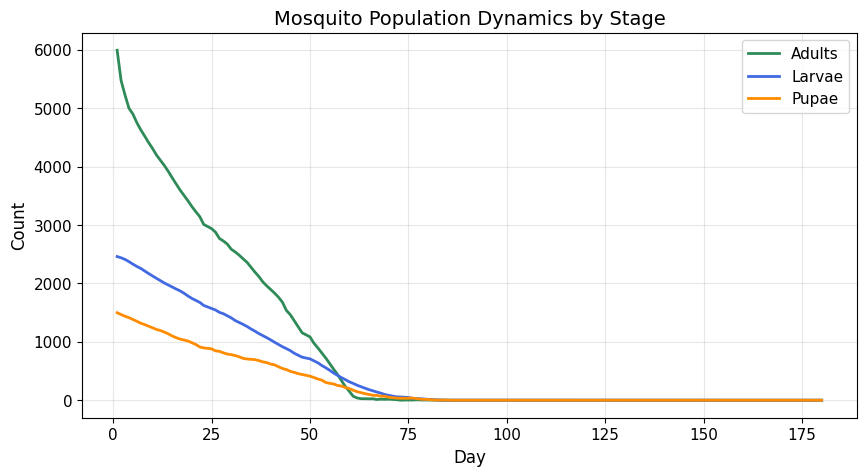

Theoretical larval duration at 13.5°C: 40.79 days
Theoretical pupal duration at 13.5°C: 6.11 days

--- Estimating from simulation data (cross‑correlation method) ---
Data‑based larval duration: not reliable (population still increasing).
Data‑based pupal duration: not reliable (population still increasing).

✅ Adopted larval duration: 40.8 days
✅ Adopted pupal duration: 6.1 days


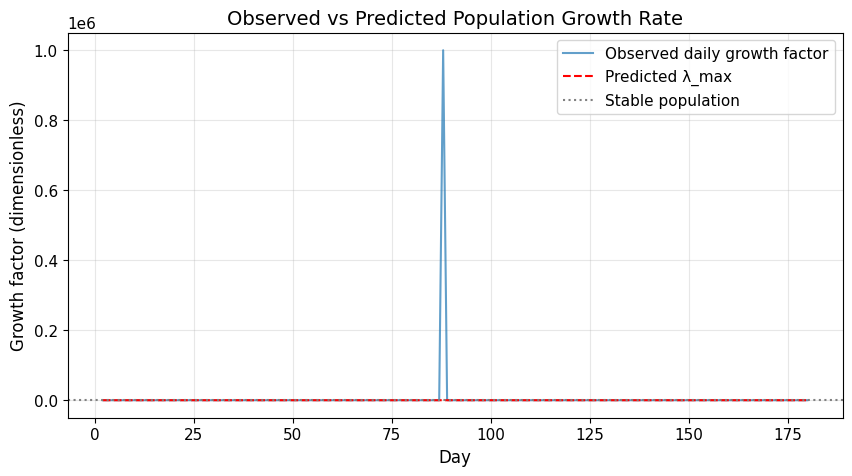

Average predicted λ_max (temp‑dependent adult mortality): 0.966


In [16]:
# ---- Plot population dynamics ----
plt.figure(figsize=(10,5))
plt.plot(daily_living['Day'], daily_living['AdultCount'], label='Adults', color=STAGE_COLORS['ADULT'], linewidth=2)
plt.plot(daily_living['Day'], daily_living['LarvaCount'], label='Larvae', color=STAGE_COLORS['LARVA'], linewidth=2)
plt.plot(daily_living['Day'], daily_living['PupaCount'], label='Pupae', color=STAGE_COLORS['PUPA'], linewidth=2)
plt.xlabel('Day')
plt.ylabel('Count')
plt.title('Mosquito Population Dynamics by Stage')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f'{OUTPUT_DIR}/mosquito_dynamics.png', dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------
# Species parameters – EXACTLY as in simulation.yaml
# ------------------------------------------------------------------
params_species = {
    "egg_dev_rho": 0.005000000000000001,
    "egg_dev_k": 39.20841161317061,
    "egg_dev_Delta": 1.9999999999999998,
    "egg_dev_lambda": -0.854916887158478,
    "larva_dev_a": 2.7054689312186438e-05,
    "larva_dev_Tmin": 5.123026541348266,
    "larva_dev_Tmax": 44.999999999835175,
    "larva_dev_m": 1.663077023745059,
    "pupa_dev_rho": 0.005115463305281753,
    "pupa_dev_k": 39.940257466039114,
    "pupa_dev_Delta": 1.9999999999999998,
    "pupa_dev_lambda": -0.9081661833839708,
    "egg_mort_b1": 3.572876,
    "egg_mort_b2": -0.323474,
    "egg_mort_b3": 0.004941,
    "larva_mort_b1": 1.9999999999999998,
    "larva_mort_b2": -0.7395036647759831,
    "larva_mort_b3": 0.017491023810106067,
    "pupa_mort_b1": 5.882576,
    "pupa_mort_b2": -0.578528,
    "pupa_mort_b3": 0.009458,
    "fecundity_rmax": 1.6021994175985133,
    "fecundity_Topt": 30.634033187663604,
    "fecundity_c": -0.0052723551194922445,
    "adult_mort_b1": -1.4775,
    "adult_mort_b2": -0.1377,
    "adult_mort_b3": 0.003908,
    "adult_mortality_per_day": 0.1198, 
    "sex_ratio": 0.5,
}

# ---- Helper functions (same as simulation's LifecycleModel) ----
def egg_development_rate(T_C):
    rho = params_species['egg_dev_rho']
    k = params_species['egg_dev_k']
    Delta = params_species['egg_dev_Delta']
    lam = params_species['egg_dev_lambda']
    exp_arg = rho * k - (k - T_C) / Delta
    # exp_arg = np.clip(exp_arg, -700, 700)
    val = np.exp(rho * T_C - np.exp(exp_arg)) + lam
    return max(0, val)

def larva_development_rate(T_C):
    a = params_species['larva_dev_a']
    Tmin = params_species['larva_dev_Tmin']
    Tmax = params_species['larva_dev_Tmax']
    m = params_species['larva_dev_m']
    if T_C <= Tmin or T_C >= Tmax:
        return 0.0
    val = a * T_C * (T_C - Tmin) * (Tmax - T_C) ** (1.0/m)
    return max(0, val)

def pupa_development_rate(T_C):
    rho = params_species['pupa_dev_rho']
    k = params_species['pupa_dev_k']
    Delta = params_species['pupa_dev_Delta']
    lam = params_species['pupa_dev_lambda']
    exp_arg = rho * k - (k - T_C) / Delta
    # exp_arg = np.clip(exp_arg, -700, 700)
    val = np.exp(rho * T_C - np.exp(exp_arg)) + lam
    return max(0, val)

def egg_mortality_rate(T_C):
    return np.exp(params_species['egg_mort_b1'] + params_species['egg_mort_b2']*T_C + params_species['egg_mort_b3']*T_C**2)

def larva_mortality_rate(T_C):
    return np.exp(params_species['larva_mort_b1'] + params_species['larva_mort_b2']*T_C + params_species['larva_mort_b3']*T_C**2)

def pupa_mortality_rate(T_C):
    return np.exp(params_species['pupa_mort_b1'] + params_species['pupa_mort_b2']*T_C + params_species['pupa_mort_b3']*T_C**2)

def adult_mortality_rate(T_C):
    # Temperature‑dependent as used in simulation
    return np.exp(params_species['adult_mort_b1'] + params_species['adult_mort_b2']*T_C + params_species['adult_mort_b3']*T_C**2)

def fecundity_rate(T_C):
    rmax = params_species['fecundity_rmax']
    Topt = params_species['fecundity_Topt']
    c = params_species['fecundity_c']
    Sr = params_species['sex_ratio']
    val = np.exp(rmax + c * (Topt - T_C)**2)
    return max(0, val) * Sr

# ---- Theoretical durations at mean temperature ----
def theoretical_duration(rate_func, temp_celsius):
    rate = rate_func(temp_celsius)
    return 1.0 / rate if rate > 0 else np.inf

temp_col = None
for col, disp, _, _, _ in ENV_VARS:
    if 'temp' in col.lower() or disp.lower() == 'temperature':
        temp_col = f'Mean{disp}'
        break

if temp_col is not None and temp_col in daily_living.columns:
    mean_temp = daily_living[temp_col].mean()
    theo_larval = theoretical_duration(larva_development_rate, mean_temp)
    theo_pupal = theoretical_duration(pupa_development_rate, mean_temp)
    print(f"Theoretical larval duration at {mean_temp:.1f}°C: {theo_larval:.2f} days")
    print(f"Theoretical pupal duration at {mean_temp:.1f}°C: {theo_pupal:.2f} days")
else:
    print("Could not compute theoretical durations – temperature column missing.")

# ---- Estimate stage duration from simulation data (cross‑correlation) ----
from scipy.ndimage import uniform_filter1d

def estimate_stage_duration_cross_corr(df, stage_from, stage_to, ticks_per_day=96, smooth_window=5):
    s1 = df[f'{stage_from}Count'].values.astype(float)
    s2 = df[f'{stage_to}Count'].values.astype(float)
    # Ensure same length
    last = max(np.flatnonzero(s1)[-1] if np.any(s1) else 0,
               np.flatnonzero(s2)[-1] if np.any(s2) else 0)
    s1 = s1[:last+1]
    s2 = s2[:last+1]
    if smooth_window > 1:
        s1 = uniform_filter1d(s1, size=smooth_window, mode='nearest')
        s2 = uniform_filter1d(s2, size=smooth_window, mode='nearest')
    # Cross‑correlation
    corr = correlate(s1, s2, mode='full')
    lags = correlation_lags(len(s1), len(s2), mode='full')
    peak_lag = lags[np.argmax(corr)]
    lag_days = peak_lag / ticks_per_day
    return lag_days if lag_days > 0 else None

print("\n--- Estimating from simulation data (cross‑correlation method) ---")
larval_days = estimate_stage_duration_cross_corr(daily_living, 'Larva', 'Pupa', TICKS_PER_DAY)
pupal_days = estimate_stage_duration_cross_corr(daily_living, 'Pupa', 'Adult', TICKS_PER_DAY)

if larval_days:
    print(f"Data‑based larval duration: {larval_days:.1f} days")
else:
    print("Data‑based larval duration: not reliable (population still increasing).")
if pupal_days:
    print(f"Data‑based pupal duration: {pupal_days:.1f} days")
else:
    print("Data‑based pupal duration: not reliable (population still increasing).")

final_larval = larval_days if larval_days else theo_larval
final_pupal = pupal_days if pupal_days else theo_pupal
if final_larval and final_pupal:
    print(f"\n✅ Adopted larval duration: {final_larval:.1f} days")
    print(f"✅ Adopted pupal duration: {final_pupal:.1f} days")
else:
    print("\n⚠️ Could not obtain either estimate – simulation may be too short.")


def discrete_lambda_max(T_C, livestock_density, params):
    rE = egg_development_rate(T_C)
    rL = larva_development_rate(T_C)
    rP = pupa_development_rate(T_C)

    muE = egg_mortality_rate(T_C)
    muL = larva_mortality_rate(T_C)
    muP = pupa_mortality_rate(T_C)
    muA = adult_mortality_rate(T_C)    # temperature‑dependent

    # Daily stage transition probabilities (as in simulation)
    pDevE = 1.0 - np.exp(-rE)
    pSurvE = np.exp(-muE)
    pDevL = 1.0 - np.exp(-rL)
    pSurvL = np.exp(-muL)
    pDevP = 1.0 - np.exp(-rP)
    pSurvP = np.exp(-muP)
    pSurvA = np.exp(-muA)

    F = fecundity_rate(T_C)
    K = 1 + np.log1p(max(0, livestock_density))
    eggs_per_female = F * K

    A_mat = np.array([
        [(1 - pDevE) * pSurvE, 0, 0, eggs_per_female],
        [pDevE * pSurvE, (1 - pDevL) * pSurvL, 0, 0],
        [0, pDevL * pSurvL, (1 - pDevP) * pSurvP, 0],
        [0, 0, pDevP * pSurvP, pSurvA]
    ])

    eigvals = np.linalg.eigvals(A_mat)
    return np.max(eigvals.real)

livestock_density = 0.5   # consistent with simulation default

if temp_col is not None and temp_col in daily_living.columns:
    lambda_vals = [discrete_lambda_max(temp, livestock_density, params_species) for temp in daily_living[temp_col]]
    adult_counts = daily_living['AdultCount'].values
    observed_growth = adult_counts[1:] / (adult_counts[:-1] + 1e-6)
    days_obs = daily_living['Day'].values[1:]

    plt.figure(figsize=(10,5))
    plt.plot(days_obs, observed_growth, label='Observed daily growth factor', alpha=0.7)
    plt.plot(days_obs, lambda_vals[1:], label='Predicted λ_max', linestyle='--', color='red')
    plt.axhline(1, color='gray', linestyle=':', label='Stable population')
    plt.xlabel('Day')
    plt.ylabel('Growth factor (dimensionless)')
    plt.title('Observed vs Predicted Population Growth Rate')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(f'{OUTPUT_DIR}/growth_validation.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Average predicted λ_max (temp‑dependent adult mortality): {np.mean(lambda_vals):.3f}")
else:
    print("No temperature column found – skipping validation.")

# 3. Water Tank Statistics

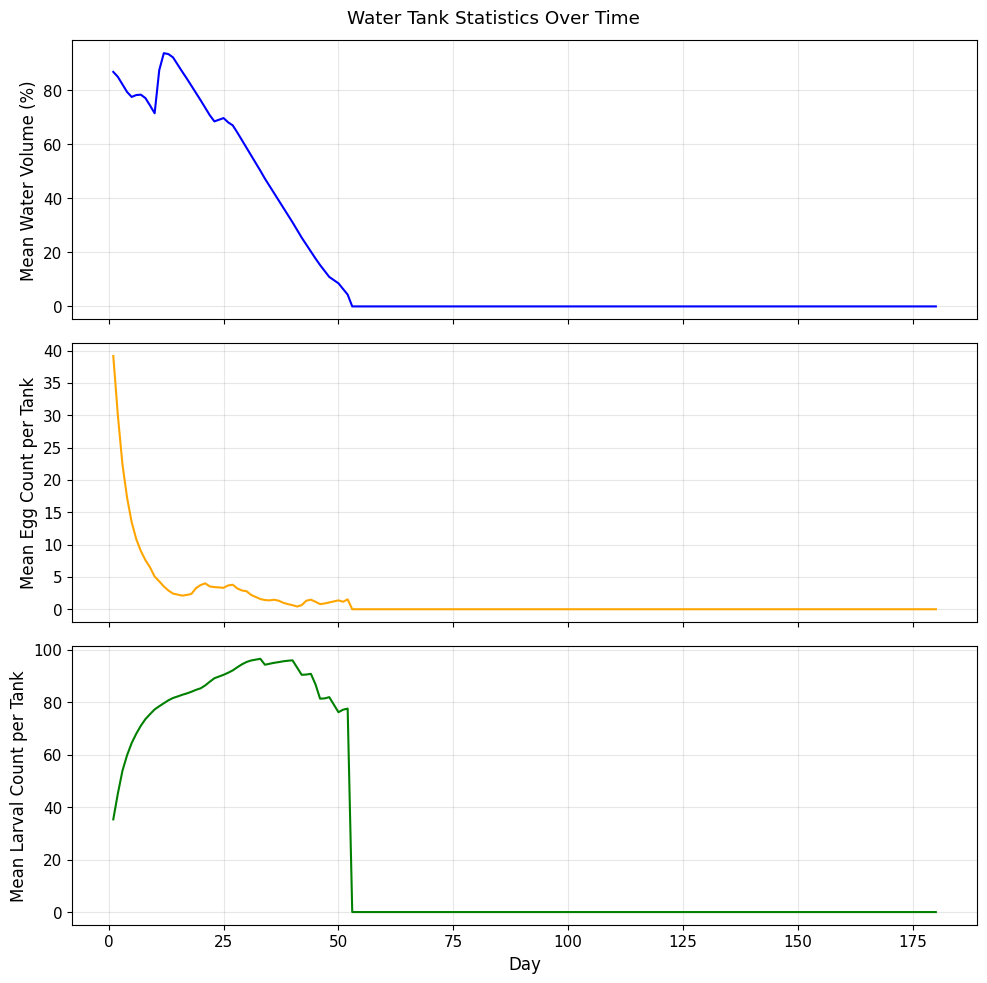

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
axes[0].plot(daily_inert['Day'], daily_inert['MeanWaterVolume'], color='blue')
axes[0].set_ylabel('Mean Water Volume (%)'); axes[0].grid(True, alpha=0.3)
axes[1].plot(daily_inert['Day'], daily_inert['TotalEggs'] / daily_inert['TankCount'].clip(lower=1), color='orange')
axes[1].set_ylabel('Mean Egg Count per Tank'); axes[1].grid(True, alpha=0.3)
axes[2].plot(daily_inert['Day'], daily_inert['TotalLarvae'] / daily_inert['TankCount'].clip(lower=1), color='green')
axes[2].set_ylabel('Mean Larval Count per Tank'); axes[2].set_xlabel('Day'); axes[2].grid(True, alpha=0.3)
plt.suptitle('Water Tank Statistics Over Time')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/tank_stats.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Environmental Correlation

Uses daily aggregated temperature (converted to Celsius) and precipitation (converted to mm).

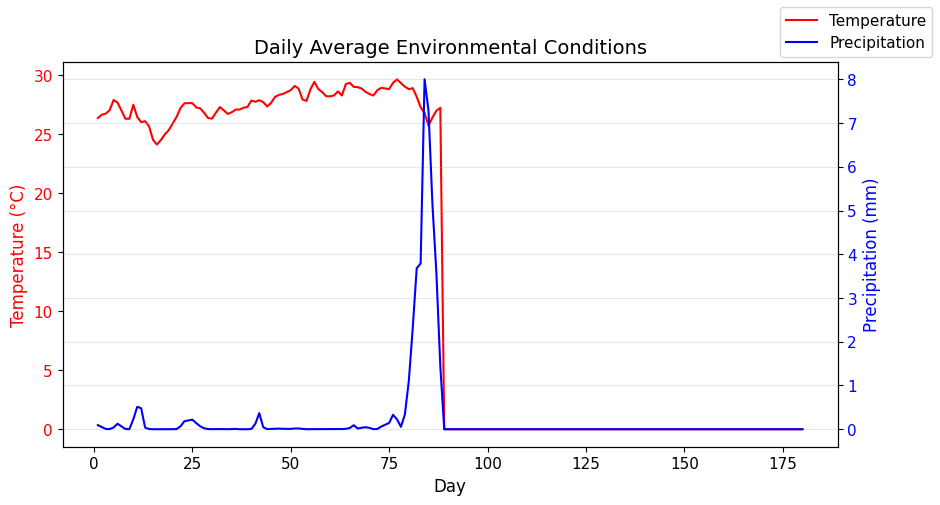

Correlation adult count vs Temperature: r=0.563 (p=7.908e-16)
Correlation adult count vs Precipitation: r=-0.095 (p=2.120e-01)


In [18]:
if len(ENV_VARS) == 1:
    col, disp, unit, _, _ = ENV_VARS[0]
    mean_col = f'Mean{disp}'
    plt.figure(figsize=(10,5))
    plt.plot(daily_living['Day'], daily_living[mean_col], color='red')
    plt.ylabel(f'{disp} ({unit})', color='red')
    plt.xlabel('Day'); plt.title(f'Daily Average {disp}'); plt.grid(True, alpha=0.3)
    plt.savefig(f'{OUTPUT_DIR}/environment.png', dpi=300, bbox_inches='tight'); plt.show()
else:
    fig, ax1 = plt.subplots(figsize=(10,5))
    ax1.set_xlabel('Day')
    axes = [ax1]; colors = ['red','blue','green','orange','purple']
    for i, (col, disp, unit, _, _) in enumerate(ENV_VARS):
        mean_col = f'Mean{disp}'
        if i == 0:
            ax = ax1
            ax.set_ylabel(f'{disp} ({unit})', color=colors[i]); ax.tick_params(axis='y', labelcolor=colors[i])
        else:
            ax = ax1.twinx()
            ax.set_ylabel(f'{disp} ({unit})', color=colors[i]); ax.tick_params(axis='y', labelcolor=colors[i])
            axes.append(ax)
        ax.plot(daily_living['Day'], daily_living[mean_col], color=colors[i], label=disp)
    fig.legend(loc='upper right')
    plt.title('Daily Average Environmental Conditions')
    plt.grid(True, alpha=0.3)
    plt.savefig(f'{OUTPUT_DIR}/environment.png', dpi=300, bbox_inches='tight'); plt.show()

adult_series = daily_living['AdultCount'].values
for col, disp, unit, _, _ in ENV_VARS:
    mean_col = f'Mean{disp}'
    if mean_col in daily_living.columns:
        var_series = daily_living[mean_col].values
        corr, p = pearsonr(adult_series, var_series)
        print(f"Correlation adult count vs {disp}: r={corr:.3f} (p={p:.3e})")

# 5. Suitability Maps & GeoTIFF Export

KDE of adult mosquito positions and rasterised tank load (eggs+larvae) at the last tick.

Adult points collected: 154223
Using last tick 1200 for tank load.
Tank load data collected: 19 tanks
KDE extent: x=[38.201406, 48.877952], y=[2.637629, 11.866121]
Adult suitability raster saved to /mnt/monadworld/projects/phd/article_manuscripts/new/figs/somali/adult_suitability.tif


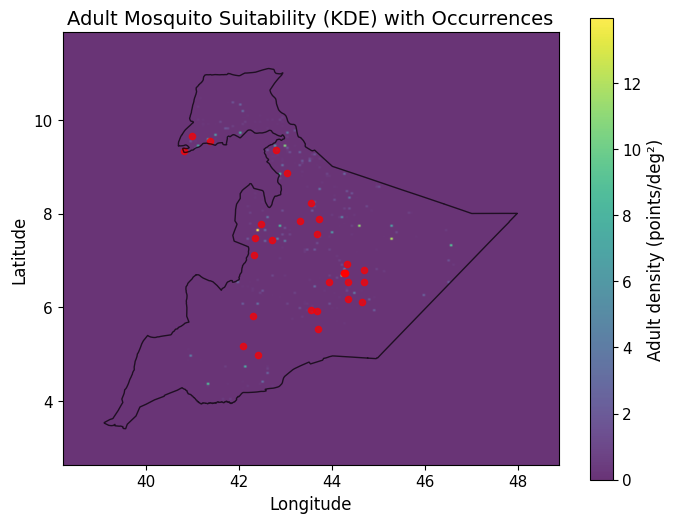

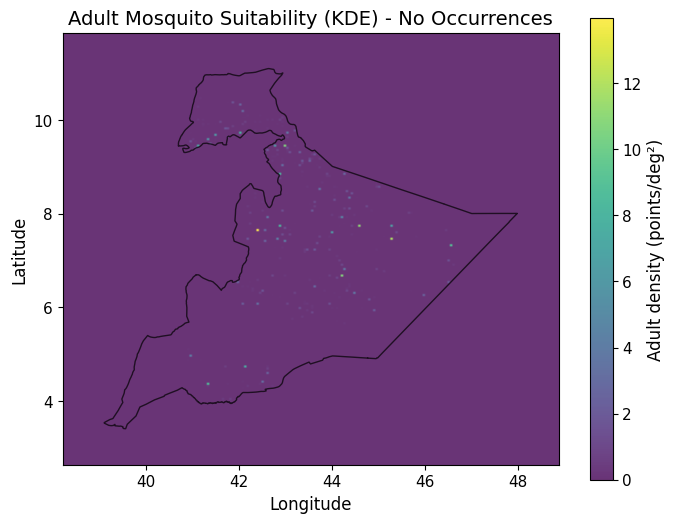

Breeding site potential raster saved to /mnt/monadworld/projects/phd/article_manuscripts/new/figs/somali/breeding_site_potential.tif


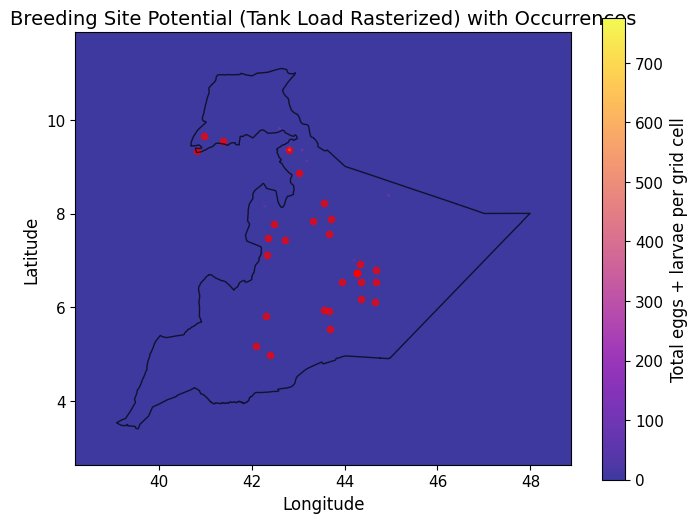

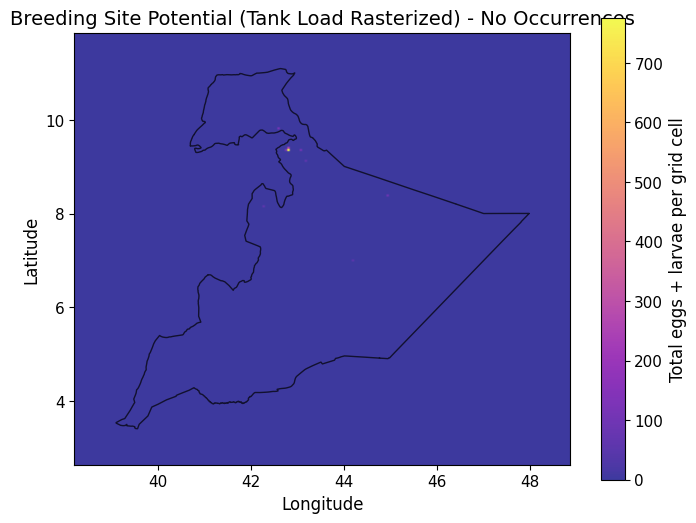

In [19]:
# ----------------------------------------------------------------------
# 1. Accumulate adult positions (spatial sampling)
# ----------------------------------------------------------------------
def accumulate_points(filepath, agent_type, stage=None, max_points=None):
    usecols = ['TickCount', 'AgentType', 'X', 'Y', 'Stage']
    all_points = []
    total = 0
    for chunk in pd.read_csv(filepath, chunksize=CHUNKSIZE, usecols=usecols, low_memory=False):
        mask = (chunk['AgentType'] == agent_type)
        if stage is not None:
            mask = mask & (chunk['Stage'] == stage)
        sub = chunk.loc[mask, ['X', 'Y']]
        if not sub.empty:
            all_points.append(sub)
            total += len(sub)
            if max_points and total >= max_points:
                break
    if not all_points:
        return pd.DataFrame()
    result = pd.concat(all_points, ignore_index=True)
    if max_points and len(result) > max_points:
        result = result.sample(n=max_points, random_state=42)
    return result

MAX_KDE_POINTS = 200000
adult_points = accumulate_points(INPUT_FILE, 'LivingAgent', stage='ADULT', max_points=MAX_KDE_POINTS)
print(f"Adult points collected: {len(adult_points)}")

# ----------------------------------------------------------------------
# 2. Tank load for the last tick
# ----------------------------------------------------------------------
last_tick = None
for chunk in pd.read_csv(INPUT_FILE, chunksize=CHUNKSIZE, usecols=['TickCount', 'AgentType'], low_memory=False):
    last_tick = chunk['TickCount'].max()
    break
print(f"Using last tick {last_tick} for tank load.")
tanks_load = []
for chunk in pd.read_csv(INPUT_FILE, chunksize=CHUNKSIZE, usecols=['TickCount', 'AgentType', 'X', 'Y', 'EggCount', 'LarvaCount'], low_memory=False):
    mask = (chunk['TickCount'] == last_tick) & (chunk['AgentType'] == 'InertAgent')
    sub = chunk.loc[mask, ['X', 'Y', 'EggCount', 'LarvaCount']]
    if not sub.empty:
        tanks_load.append(sub)
        if sum(len(df) for df in tanks_load) > 200000:
            break
if tanks_load:
    tanks_load_df = pd.concat(tanks_load, ignore_index=True)
    tanks_load_df['Load'] = tanks_load_df['EggCount'] + tanks_load_df['LarvaCount']
else:
    tanks_load_df = pd.DataFrame()
print(f"Tank load data collected: {len(tanks_load_df)} tanks")

# ----------------------------------------------------------------------
# 3. KDE creation (adults)
# ----------------------------------------------------------------------
def create_kde_suitability(points, bandwidth_deg=KDE_BANDWIDTH_DEG, grid_res=KDE_GRID_RES):
    if len(points) < 10:
        return None, None, None, None
    if study_area is not None:
        xmin, ymin, xmax, ymax = study_area.total_bounds
    else:
        xmin, xmax = points['X'].min(), points['X'].max()
        ymin, ymax = points['Y'].min(), points['Y'].max()
    dx = (xmax - xmin) * 0.1
    dy = (ymax - ymin) * 0.1
    xmin -= dx; xmax += dx; ymin -= dy; ymax += dy

    x = np.linspace(xmin, xmax, grid_res)
    y = np.linspace(ymin, ymax, grid_res)
    xx, yy = np.meshgrid(x, y)
    grid = np.vstack([xx.ravel(), yy.ravel()]).T
    kde = KernelDensity(bandwidth=bandwidth_deg, metric='euclidean')
    kde.fit(points[['X','Y']].values)
    log_dens = kde.score_samples(grid)
    dens = np.exp(log_dens).reshape(xx.shape)
    return xx, yy, dens, (xmin, xmax, ymin, ymax)

adult_kde = create_kde_suitability(adult_points)

if adult_kde[0] is not None:
    xx, yy, dens, (xmin, xmax, ymin, ymax) = adult_kde

    # ------------------------------------------------------------------
    # 4. Ensure CRS consistency
    # ------------------------------------------------------------------
    if study_area is not None:
        if study_area.crs is None:
            study_area.crs = "EPSG:4326"
        elif study_area.crs.to_epsg() != 4326:
            study_area = study_area.to_crs("EPSG:4326")
    if occurrences is not None:
        if occurrences.crs is None:
            occurrences.crs = "EPSG:4326"
        elif occurrences.crs.to_epsg() != 4326:
            occurrences = occurrences.to_crs("EPSG:4326")

    print(f"KDE extent: x=[{xmin:.6f}, {xmax:.6f}], y=[{ymin:.6f}, {ymax:.6f}]")

    # ------------------------------------------------------------------
    # 5. Export GeoTIFF (NO FLIP)
    # ------------------------------------------------------------------
    if EXPORT_RASTERS:
        transform = from_origin(xmin, ymax,
                                (xmax - xmin) / dens.shape[1],
                                (ymax - ymin) / dens.shape[0])
        adult_tif = os.path.join(OUTPUT_DIR, 'adult_suitability.tif')
        with rasterio.open(adult_tif, 'w', driver='GTiff',
                           height=dens.shape[0], width=dens.shape[1],
                           count=1, dtype=dens.dtype, crs='EPSG:4326',
                           transform=transform) as dst:
            dst.write(dens, 1)
        print(f"Adult suitability raster saved to {adult_tif}")

        # Read back for plotting
        with rasterio.open(adult_tif) as src:
            dens_geo = src.read(1)
            bounds = src.bounds
            xmin_geo, ymin_geo, xmax_geo, ymax_geo = bounds.left, bounds.bottom, bounds.right, bounds.top

        fig, ax = plt.subplots(figsize=(8,6))
        im = ax.imshow(dens_geo, extent=[xmin_geo, xmax_geo, ymin_geo, ymax_geo],
                       origin='upper', cmap='viridis', alpha=0.8)
        if study_area is not None:
            study_area.boundary.plot(ax=ax, color='black', linewidth=1, alpha=0.7)
        if occurrences is not None:
            occurrences.plot(ax=ax, color='red', marker='o', markersize=20,
                             alpha=0.7, label='Occurrences')
        plt.colorbar(im, label='Adult density (points/deg²)')
        plt.title('Adult Mosquito Suitability (KDE) with Occurrences')
        plt.xlabel('Longitude'); plt.ylabel('Latitude')
        plt.savefig(f'{OUTPUT_DIR}/adult_suitability.png', dpi=300, bbox_inches='tight')
        plt.show()

        fig, ax = plt.subplots(figsize=(8,6))
        im = ax.imshow(dens_geo, extent=[xmin_geo, xmax_geo, ymin_geo, ymax_geo],
                       origin='upper', cmap='viridis', alpha=0.8)
        if study_area is not None:
            study_area.boundary.plot(ax=ax, color='black', linewidth=1, alpha=0.7)
        plt.colorbar(im, label='Adult density (points/deg²)')
        plt.title('Adult Mosquito Suitability (KDE) - No Occurrences')
        plt.xlabel('Longitude'); plt.ylabel('Latitude')
        plt.savefig(f'{OUTPUT_DIR}/adult_suitability_no_occurrences.png', dpi=300, bbox_inches='tight')
        plt.show()

# ----------------------------------------------------------------------
# 6. Tank load raster (same grid as KDE)
# ----------------------------------------------------------------------
if not tanks_load_df.empty and EXPORT_RASTERS and adult_kde[0] is not None:
    grid_res = KDE_GRID_RES
    x_edges = np.linspace(xmin, xmax, grid_res + 1)
    y_edges = np.linspace(ymin, ymax, grid_res + 1)

    load_raster, _, _ = np.histogram2d(tanks_load_df['X'], tanks_load_df['Y'],
                                       bins=[x_edges, y_edges],
                                       weights=tanks_load_df['Load'])
    load_raster = load_raster.T

    transform = from_origin(xmin, ymax,
                            (xmax - xmin) / grid_res,
                            (ymax - ymin) / grid_res)
    tank_tif = os.path.join(OUTPUT_DIR, 'breeding_site_potential.tif')
    with rasterio.open(tank_tif, 'w', driver='GTiff',
                       height=grid_res, width=grid_res,
                       count=1, dtype=load_raster.dtype, crs='EPSG:4326',
                       transform=transform) as dst:
        dst.write(load_raster, 1)
    print(f"Breeding site potential raster saved to {tank_tif}")

    with rasterio.open(tank_tif) as src:
        tank_geo = src.read(1)
        bounds = src.bounds
        xmin_t, ymin_t, xmax_t, ymax_t = bounds.left, bounds.bottom, bounds.right, bounds.top

    fig, ax = plt.subplots(figsize=(8,6))
    im = ax.imshow(tank_geo, extent=[xmin_t, xmax_t, ymin_t, ymax_t],
                   origin='upper', cmap='plasma', alpha=0.8)
    if study_area is not None:
        study_area.boundary.plot(ax=ax, color='black', linewidth=1, alpha=0.7)
    if occurrences is not None:
        occurrences.plot(ax=ax, color='red', marker='o', markersize=20,
                         alpha=0.7, label='Occurrences')
    plt.colorbar(im, label='Total eggs + larvae per grid cell')
    plt.title('Breeding Site Potential (Tank Load Rasterized) with Occurrences')
    plt.xlabel('Longitude'); plt.ylabel('Latitude')
    plt.savefig(f'{OUTPUT_DIR}/breeding_site_potential.png', dpi=300, bbox_inches='tight')
    plt.show()

    fig, ax = plt.subplots(figsize=(8,6))
    im = ax.imshow(tank_geo, extent=[xmin_t, xmax_t, ymin_t, ymax_t],
                   origin='upper', cmap='plasma', alpha=0.8)
    if study_area is not None:
        study_area.boundary.plot(ax=ax, color='black', linewidth=1, alpha=0.7)
    plt.colorbar(im, label='Total eggs + larvae per grid cell')
    plt.title('Breeding Site Potential (Tank Load Rasterized) - No Occurrences')
    plt.xlabel('Longitude'); plt.ylabel('Latitude')
    plt.savefig(f'{OUTPUT_DIR}/breeding_site_potential_no_occurrences.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No tank load data or KDE missing – cannot export breeding site raster.")

WATER VOLUME - POPULATION RELATIONSHIP ANALYSIS
MeanWaterVolume vs AdultCount: r=0.973 (p=8.527e-111)
TotalEggs vs AdultCount: r=0.727 (p=1.117e-29)
TotalLarvae vs AdultCount: r=0.813 (p=6.225e-42)


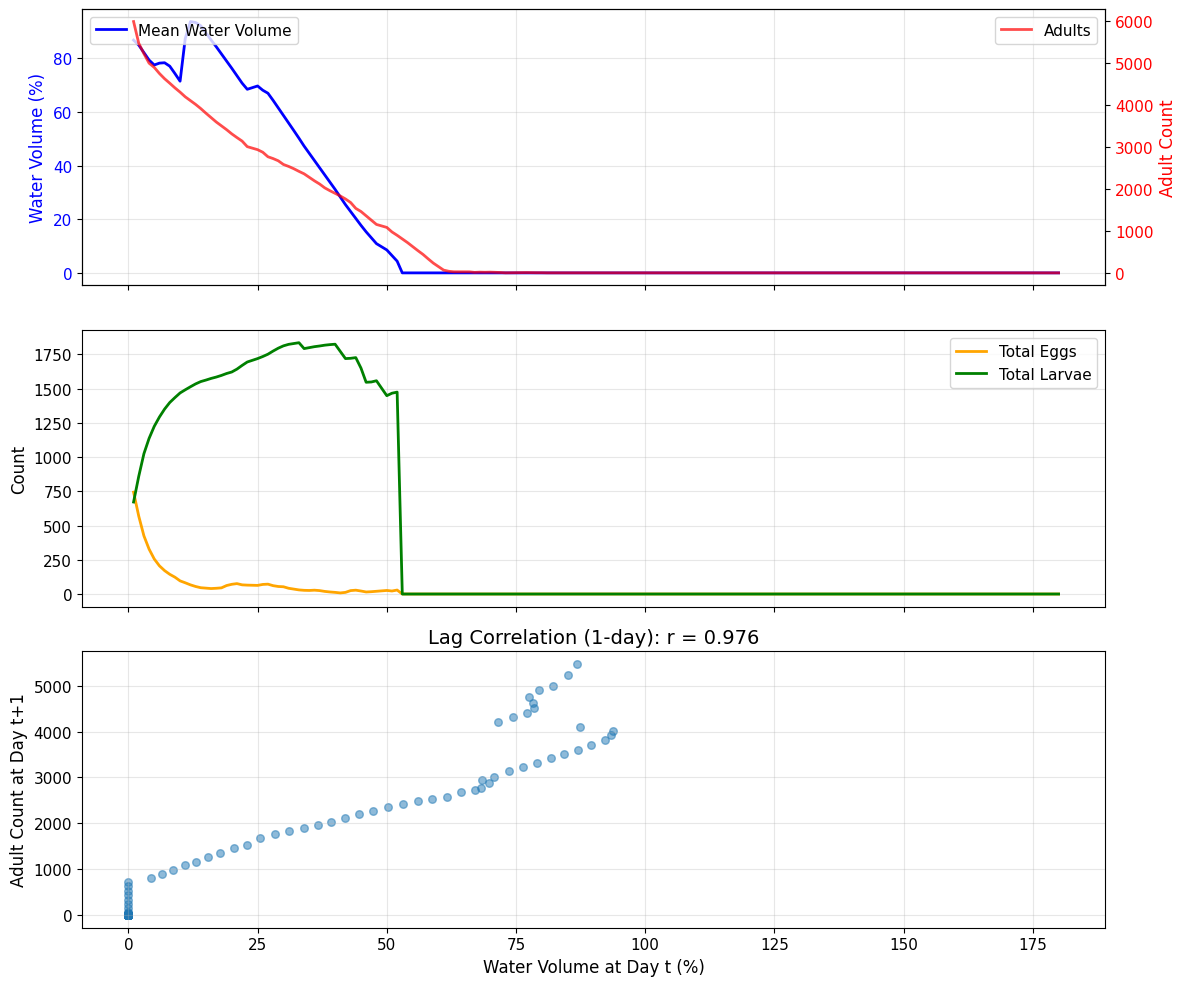


λ_max VALIDATION AGAINST OBSERVED GROWTH
Observed early growth rate (λ): -0.034 per day
Predicted λ_max (from simulation): 0.966
Ratio (observed/predicted): -0.036

SENSITIVITY ANALYSIS
Monte Carlo results loaded successfully:
  Runs: 67
  Peak adults: 6199 ± 1216

PUBLICATION-READY SUMMARY


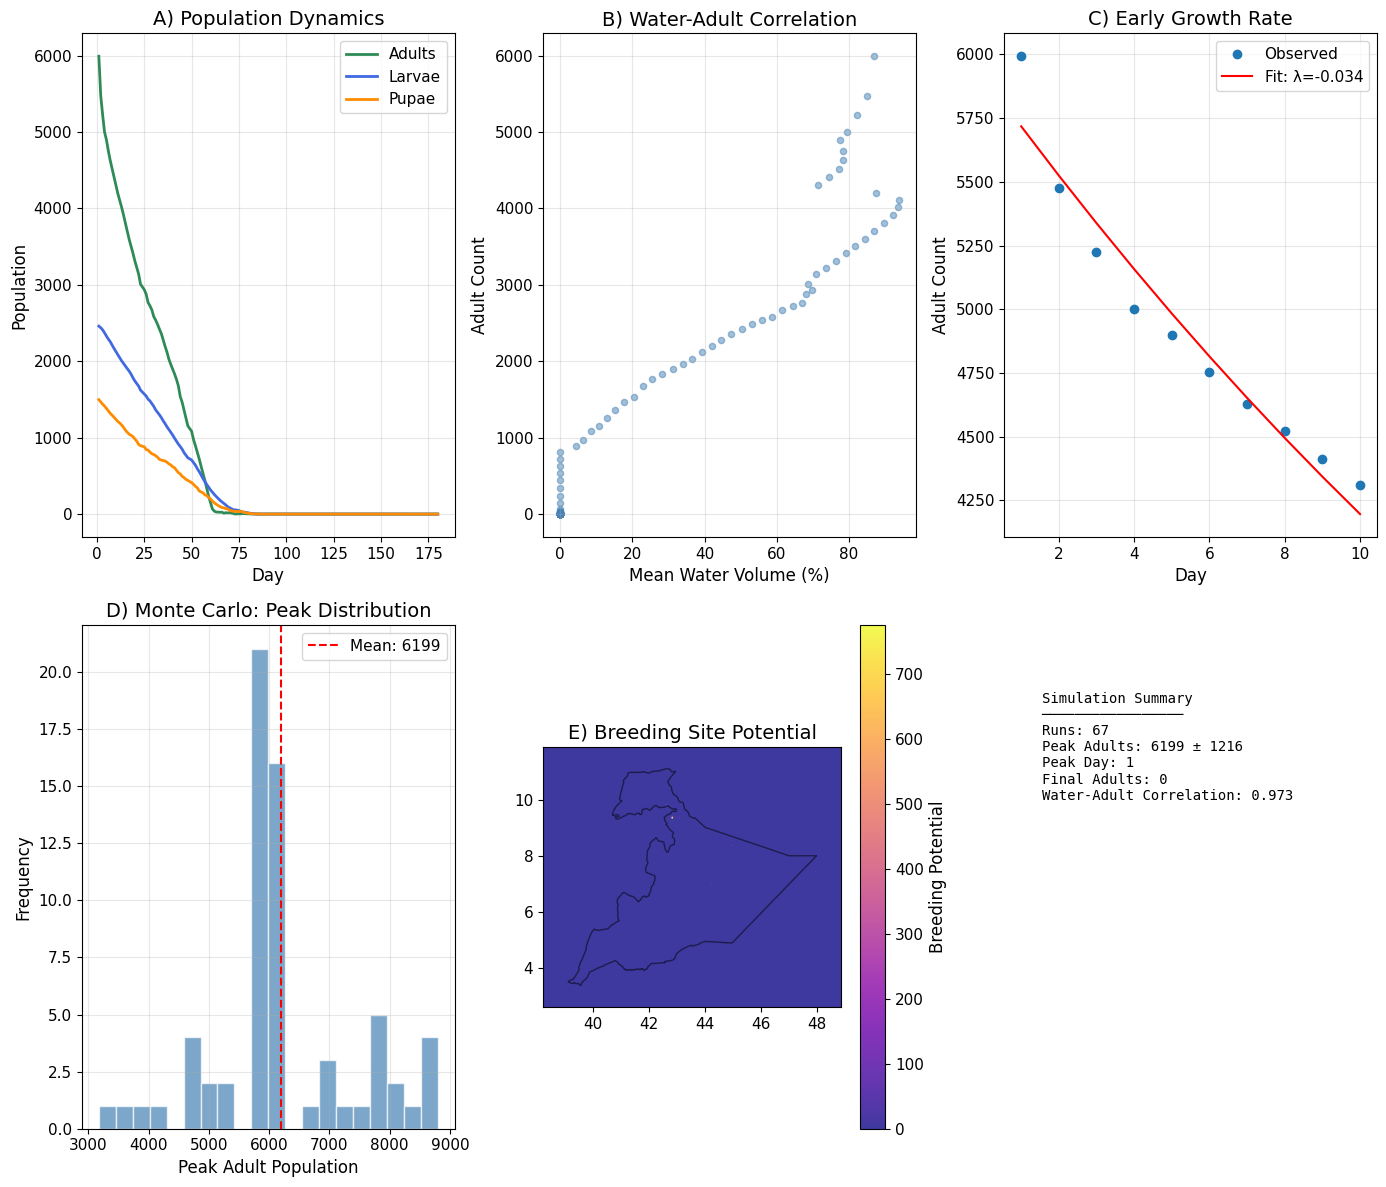


✅ Combined figure saved to: /mnt/monadworld/projects/phd/article_manuscripts/new/figs/somali/manuscript_figure_combined.png


In [20]:
# Add this to a new cell in your notebook

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from scipy.signal import find_peaks
import seaborn as sns

# ======================================================================
# 1. WATER VOLUME - POPULATION RELATIONSHIP
# ======================================================================

print("="*60)
print("WATER VOLUME - POPULATION RELATIONSHIP ANALYSIS")
print("="*60)

# Load your daily summary data
daily_summary = pd.read_csv(f'{OUTPUT_DIR}/daily_summary.csv')

# Calculate correlations between tank metrics and adult population
tank_metrics = ['MeanWaterVolume', 'TotalEggs', 'TotalLarvae']
correlations = {}

for metric in tank_metrics:
    if metric in daily_summary.columns:
        corr, p = pearsonr(daily_summary[metric].fillna(0), 
                          daily_summary['AdultCount'].fillna(0))
        correlations[metric] = {'correlation': corr, 'p_value': p}
        print(f"{metric} vs AdultCount: r={corr:.3f} (p={p:.3e})")

# Create figure showing water dynamics and population
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Plot 1: Water volume and adults
ax1 = axes[0]
ax1.plot(daily_summary['Day'], daily_summary['MeanWaterVolume'], 
         color='blue', linewidth=2, label='Mean Water Volume')
ax1.set_ylabel('Water Volume (%)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

ax1b = ax1.twinx()
ax1b.plot(daily_summary['Day'], daily_summary['AdultCount'], 
         color='red', linewidth=2, alpha=0.7, label='Adults')
ax1b.set_ylabel('Adult Count', color='red')
ax1b.tick_params(axis='y', labelcolor='red')
ax1b.legend(loc='upper right')

# Plot 2: Eggs and larvae
ax2 = axes[1]
ax2.plot(daily_summary['Day'], daily_summary['TotalEggs'], 
         color='orange', linewidth=2, label='Total Eggs')
ax2.plot(daily_summary['Day'], daily_summary['TotalLarvae'], 
         color='green', linewidth=2, label='Total Larvae')
ax2.set_ylabel('Count')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Correlation scatter
ax3 = axes[2]
# Use lagged relationships (water at day t vs adults at day t+1)
water_lag = daily_summary['MeanWaterVolume'].shift(1).dropna()
adults_next = daily_summary['AdultCount'].shift(-1).dropna()
min_len = min(len(water_lag), len(adults_next))
ax3.scatter(water_lag.iloc[:min_len], adults_next.iloc[:min_len], 
           alpha=0.5, s=30)
corr_lag, _ = pearsonr(water_lag.iloc[:min_len], adults_next.iloc[:min_len])
ax3.set_xlabel('Water Volume at Day t (%)')
ax3.set_ylabel('Adult Count at Day t+1')
ax3.set_title(f'Lag Correlation (1-day): r = {corr_lag:.3f}')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/water_population_relationship.png', dpi=300, bbox_inches='tight')
plt.show()

# ======================================================================
# 2. VALIDATE λ_max AGAINST OBSERVED GROWTH
# ======================================================================

print("\n" + "="*60)
print("λ_max VALIDATION AGAINST OBSERVED GROWTH")
print("="*60)

# Calculate observed growth rate over the full simulation
from scipy.optimize import curve_fit

# Fit exponential growth to the early phase
def exp_growth(t, a, b):
    return a * np.exp(b * t)

# Use early data (first 500 ticks / ~5 days)
days_early = daily_summary['Day'][:10].values
adults_early = daily_summary['AdultCount'][:10].values

try:
    popt, _ = curve_fit(exp_growth, days_early, adults_early, p0=[adults_early[0], 0.1])
    observed_growth_rate = popt[1]
    print(f"Observed early growth rate (λ): {observed_growth_rate:.3f} per day")
    print(f"Predicted λ_max (from simulation): {np.mean(lambda_vals):.3f}")
    print(f"Ratio (observed/predicted): {observed_growth_rate / np.mean(lambda_vals):.3f}")
except:
    print("Could not fit growth curve")

# ======================================================================
# 3. SENSITIVITY ANALYSIS
# ======================================================================

print("\n" + "="*60)
print("SENSITIVITY ANALYSIS")
print("="*60)

# Analyze how peak adult population varies with key parameters
# We'll use your Monte Carlo results

# Check if we have parameter information in your results
if 'seed' in df_results.columns:
    # Extract seed info if available
    print("Analyzing run-to-run variability...")
    print(f"  CV (Coefficient of Variation): {df_results['peak_adults'].std() / df_results['peak_adults'].mean():.3f}")
    print(f"  IQR: {df_results['peak_adults'].quantile(0.75) - df_results['peak_adults'].quantile(0.25):.0f}")
else:
    print("Monte Carlo results loaded successfully:")
    print(f"  Runs: {len(df_results)}")
    print(f"  Peak adults: {df_results['peak_adults'].mean():.0f} ± {df_results['peak_adults'].std():.0f}")

# ======================================================================
# 4. GENERATE PUBLICATION-READY SUMMARY
# ======================================================================

print("\n" + "="*60)
print("PUBLICATION-READY SUMMARY")
print("="*60)

# Create a comprehensive figure for your manuscript
fig = plt.figure(figsize=(14, 12))

# Panel A: Population dynamics
ax1 = plt.subplot(2, 3, 1)
ax1.plot(daily_summary['Day'], daily_summary['AdultCount'], 
         color='#2E8B57', linewidth=2, label='Adults')
ax1.plot(daily_summary['Day'], daily_summary['LarvaCount'], 
         color='#4169E1', linewidth=2, label='Larvae')
ax1.plot(daily_summary['Day'], daily_summary['PupaCount'], 
         color='#FF8C00', linewidth=2, label='Pupae')
ax1.set_xlabel('Day')
ax1.set_ylabel('Population')
ax1.set_title('A) Population Dynamics')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Panel B: Water volume and adult correlation
ax2 = plt.subplot(2, 3, 2)
ax2.scatter(daily_summary['MeanWaterVolume'], daily_summary['AdultCount'], 
           alpha=0.5, s=20, c='steelblue')
ax2.set_xlabel('Mean Water Volume (%)')
ax2.set_ylabel('Adult Count')
ax2.set_title('B) Water-Adult Correlation')
ax2.grid(True, alpha=0.3)

# Panel C: Growth rate validation
ax3 = plt.subplot(2, 3, 3)
if 'lambda_vals' in locals():
    ax3.plot(days_early, adults_early, 'o', label='Observed')
    ax3.plot(days_early, exp_growth(np.array(days_early), *popt), 
             'r-', label=f'Fit: λ={popt[1]:.3f}')
    ax3.set_xlabel('Day')
    ax3.set_ylabel('Adult Count')
    ax3.set_title('C) Early Growth Rate')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

# Panel D: Monte Carlo peak distribution (using your results)
ax4 = plt.subplot(2, 3, 4)
ax4.hist(df_results['peak_adults'], bins=20, edgecolor='white', 
         alpha=0.7, color='steelblue')
ax4.axvline(peak_mean, color='red', linestyle='--', 
            label=f'Mean: {peak_mean:.0f}')
ax4.set_xlabel('Peak Adult Population')
ax4.set_ylabel('Frequency')
ax4.set_title('D) Monte Carlo: Peak Distribution')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Panel E: Tank load map (from your KDE)
ax5 = plt.subplot(2, 3, 5)
if 'tank_geo' in locals():
    im = ax5.imshow(tank_geo, extent=[xmin_t, xmax_t, ymin_t, ymax_t],
                    origin='upper', cmap='plasma', alpha=0.8)
    if study_area is not None:
        study_area.boundary.plot(ax=ax5, color='black', linewidth=1, alpha=0.5)
    plt.colorbar(im, ax=ax5, label='Breeding Potential')
    ax5.set_title('E) Breeding Site Potential')

# Panel F: Summary statistics
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')
text = f"""
Simulation Summary
─────────────────
Runs: {len(df_results)}
Peak Adults: {peak_mean:.0f} ± {peak_std:.0f}
Peak Day: {daily_summary['Day'][daily_summary['AdultCount'].idxmax()]:.0f}
Final Adults: {daily_summary['AdultCount'].iloc[-1]:.0f}
Water-Adult Correlation: {correlations.get('MeanWaterVolume', {}).get('correlation', 0):.3f}
"""
ax6.text(0.1, 0.9, text, transform=ax6.transAxes, fontsize=10, 
         verticalalignment='top', family='monospace')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/manuscript_figure_combined.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Combined figure saved to: {OUTPUT_DIR}/manuscript_figure_combined.png")

# 6. Validation against Real Occurrence Data (Boyce Index & Proportion in top 20%)

In [21]:
if occurrences is not None and adult_kde[0] is not None:
    xx, yy, dens, _ = adult_kde
    x_grid = xx[0,:]
    y_grid = yy[:,0]
    occ_coords = np.array([[geom.x, geom.y] for geom in occurrences.geometry])
    interp = RegularGridInterpolator((y_grid, x_grid), dens, bounds_error=False, fill_value=0)
    occ_dens = interp(occ_coords[:, [1,0]])
    threshold = np.percentile(dens[dens>0], 80)
    high_suit = occ_dens >= threshold
    accuracy = np.mean(high_suit) * 100
    print(f"Proportion of occurrence points in top 20% adult suitability: {accuracy:.1f}%")
    
    # Continuous Boyce Index
    def continuous_boyce_index(suit_raster, x_grid, y_grid, occ_coords, n_bins=20):
        suit_flat = suit_raster.ravel()
        suit_min, suit_max = np.percentile(suit_flat[suit_flat>0], [1,99])
        if suit_min == suit_max:
            suit_min = suit_flat.min()
            suit_max = suit_flat.max()
        bins = np.linspace(suit_min, suit_max, n_bins+1)
        # Expected: area proportion
        flat = suit_raster.ravel()
        area_counts = np.histogram(flat, bins=bins)[0]
        expected = area_counts / area_counts.sum()
        # Observed: occurrence proportion
        occ_vals = interp(occ_coords[:, [1,0]])
        obs_counts = np.histogram(occ_vals, bins=bins)[0]
        observed = obs_counts / obs_counts.sum()
        valid = expected > 0
        if not valid.any():
            return np.nan
        return spearmanr(observed[valid], expected[valid])[0]

    boyce = continuous_boyce_index(dens, x_grid, y_grid, occ_coords)
    print(f"Continuous Boyce Index = {boyce:.3f}")
else:
    print("Occurrence data or suitability KDE missing – cannot compute validation.")

Proportion of occurrence points in top 20% adult suitability: 46.7%
Continuous Boyce Index = 0.437


# 7. Export Tidy Data (Daily summary and a sample of the raw CSV)

In [22]:
daily_summary = pd.merge(daily_living, daily_inert, on='Day', how='outer')
daily_summary.to_csv(f'{OUTPUT_DIR}/daily_summary.csv', index=False)
sample_df = pd.read_csv(INPUT_FILE, nrows=10000)
sample_df.to_csv(f'{OUTPUT_DIR}/living_sample.csv', index=False)
print(f"Summaries saved to {OUTPUT_DIR}/")
print("Files: daily_summary.csv, living_sample.csv")
print("Analysis complete. All figures and rasters saved.")
sample_df.describe()

Summaries saved to /mnt/monadworld/projects/phd/article_manuscripts/new/figs/somali/
Files: daily_summary.csv, living_sample.csv
Analysis complete. All figures and rasters saved.


,TickCount,X,Y,Alive,Age,Energy,Gravid,EggCount,LarvaCount,waterVolume,Resting,RestingDuration,TimeWithoutRest,Elevation,Buildings,Population,t2m,tp
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,100.300000,43.199002,6.784818,0.995700,717.609500,0.643360,0.1696,0.074400,0.067200,0.165015,0.222200,0.491200,2.852500,884.103900,0.01050,69.000385,26.378464,0.093338
std,5.469277,1.289352,1.655486,0.089902,546.523755,0.170905,0.3753,1.801663,1.633754,3.803960,0.415746,1.148414,12.929194,441.483002,0.15097,295.790059,2.468125,0.173605
min,100.000000,40.698221,3.949612,-1.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1.239300,18.120000,0.000000
25%,100.000000,42.301254,5.272676,1.000000,228.000000,0.523000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,499.000000,0.00000,12.270225,24.820000,0.008500
50%,100.000000,43.050770,6.626699,1.000000,612.000000,0.657000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,858.500000,0.00000,24.876500,26.780000,0.037800
75%,100.000000,44.019727,8.078242,1.000000,1118.250000,0.762000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1176.250000,0.00000,53.400450,28.070000,0.120500
max,200.000000,46.780793,10.559212,1.000000,1988.000000,1.000000,1.0000,70.000000,58.000000,98.030000,1.000000,5.000000,97.000000,2065.000000,5.00000,6774.002900,31.330000,2.158800


MONTE CARLO ANALYSIS - PEAK ADULT POPULATION
Found 67 merged files


[1/67] merged_snapshots_20260822_144559.csv
  Analyzing: merged_snapshots_20260822_144559.csv
  Total adults across all ticks: 108,648
  Peak tick: 100 with 5,935 adults
  Final tick (6500): 3 adults
  Tick 100: 5,935 adults

[2/67] merged_snapshots_20260823_052943.csv
  Analyzing: merged_snapshots_20260823_052943.csv
  Total adults across all ticks: 146,350
  Peak tick: 100 with 4,896 adults
  Final tick (9300): 1 adults
  Tick 100: 4,896 adults

[3/67] merged_snapshots_20260822_094011.csv
  Analyzing: merged_snapshots_20260822_094011.csv
  Total adults across all ticks: 150,906
  Peak tick: 100 with 5,968 adults
  Final tick (7900): 1 adults
  Tick 100: 5,968 adults

[4/67] merged_snapshots_20260823_013658.csv
  Analyzing: merged_snapshots_20260823_013658.csv
  Total adults across all ticks: 180,283
  Peak tick: 100 with 6,944 adults
  Final tick (8600): 2 adults
  Tick 100: 6,944 adults

[5/67] merged_snapshots_202

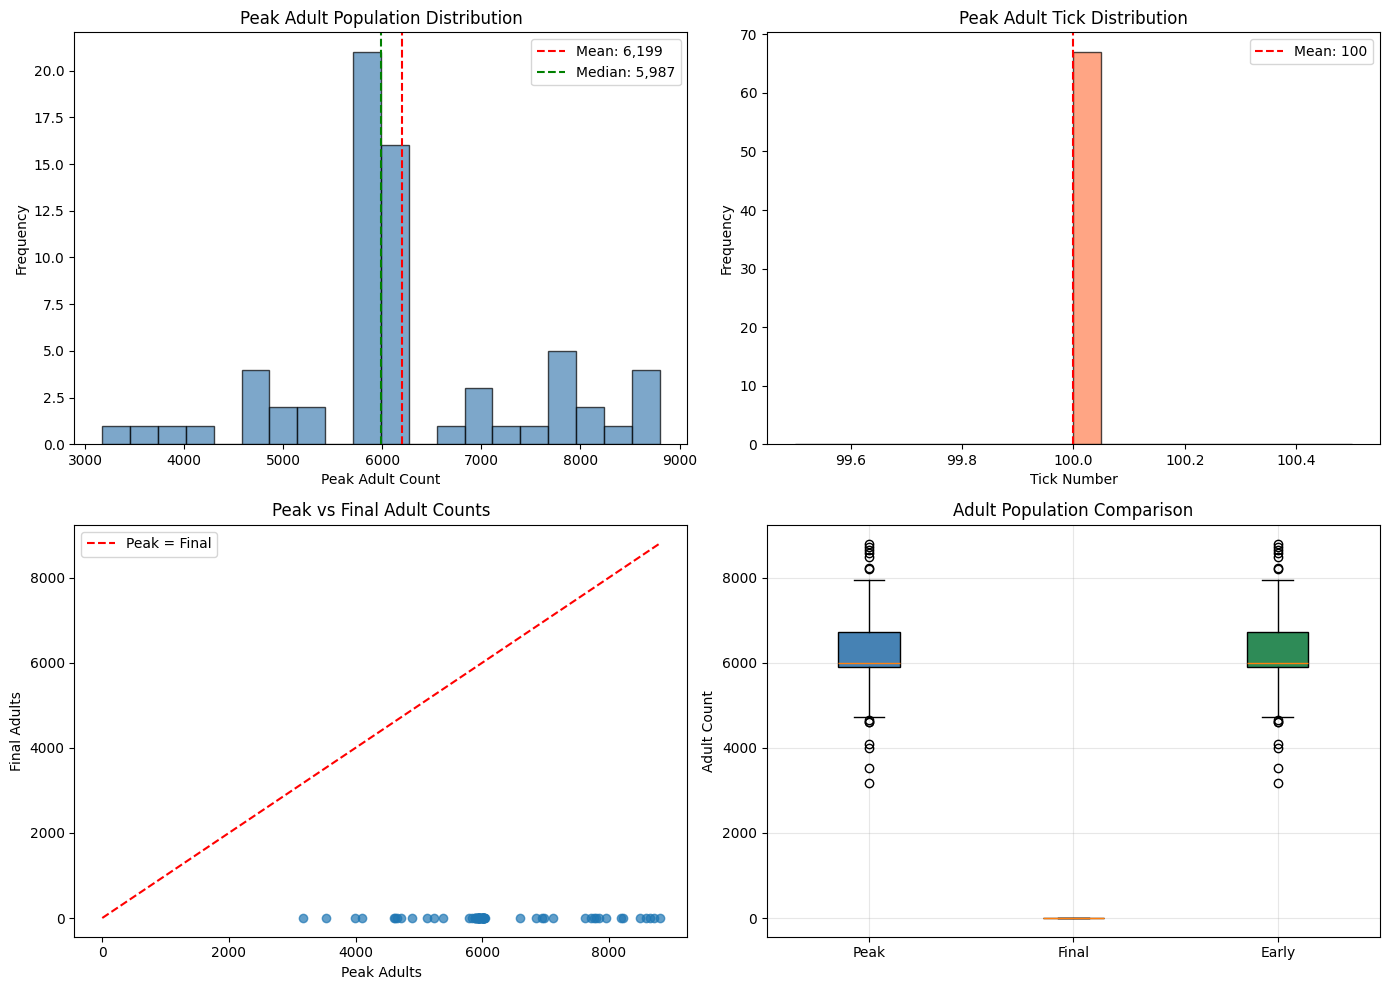

✅ Figure saved to: /mnt/monadworld/projects/phd/monte_carlo_results/monte_carlo_peak_analysis.png

TIME SERIES ANALYSIS (Sample Runs)


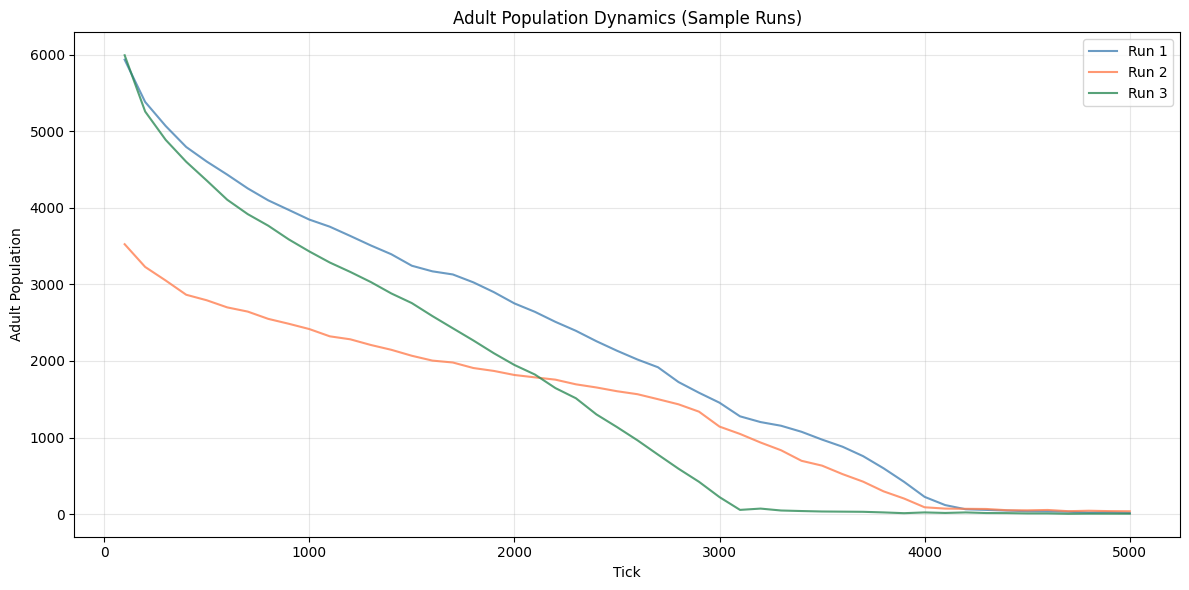

✅ Time series figure saved to: /mnt/monadworld/projects/phd/monte_carlo_results/monte_carlo_time_series.png

GENERATING COMPLETE REPORT
✅ Complete report saved to: /mnt/monadworld/projects/phd/monte_carlo_results/monte_carlo_complete_report.txt

✅ MONTE CARLO ANALYSIS COMPLETE

Results saved to: /mnt/monadworld/projects/phd/monte_carlo_results
  - monte_carlo_peak_analysis.csv (peak data)
  - monte_carlo_peak_analysis.png (visualizations)
  - monte_carlo_time_series.png (population dynamics)
  - monte_carlo_complete_report.txt (full report)


In [9]:
# ======================================================================
# MONTE CARLO ANALYSIS - FULL TICK ANALYSIS
# ======================================================================

import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from scipy.interpolate import RegularGridInterpolator
from sklearn.neighbors import KernelDensity
import warnings
warnings.filterwarnings('ignore')

# ======================================================================
# CONFIGURATION
# ======================================================================

MONTE_CARLO_DIR = "/mnt/monadworld/projects/phd/monte_carlo_results"
CHUNKSIZE = 100000
TICKS_PER_RUN = 17280  # Total ticks per simulation

# ======================================================================
# ANALYSIS FUNCTIONS
# ======================================================================

def analyze_tick_distribution(filepath):
    """
    Analyze adult distribution across all ticks in a run.
    Returns the tick with maximum adults and the peak adult count.
    """
    try:
        print(f"  Analyzing: {os.path.basename(filepath)}")
        
        # Track adults by tick
        adult_by_tick = {}
        total_adults = 0
        max_tick = 0
        max_adults = 0
        max_adults_tick = 0
        
        # Process file in chunks
        for chunk in pd.read_csv(filepath, 
                                 usecols=['TickCount', 'AgentType', 'Stage'], 
                                 chunksize=CHUNKSIZE, 
                                 low_memory=False):
            
            # Filter for adult LivingAgents
            mask = (chunk['AgentType'] == 'LivingAgent') & (chunk['Stage'] == 'ADULT')
            adults = chunk[mask]
            
            if not adults.empty:
                # Count adults per tick
                tick_counts = adults['TickCount'].value_counts()
                for tick, count in tick_counts.items():
                    adult_by_tick[tick] = adult_by_tick.get(tick, 0) + count
                    total_adults += count
                    
                    # Track max
                    if count > max_adults:
                        max_adults = count
                        max_adults_tick = tick
                    if tick > max_tick:
                        max_tick = tick
        
        # Find peak tick (maximum adults)
        if adult_by_tick:
            peak_tick = max(adult_by_tick, key=adult_by_tick.get)
            peak_adults = adult_by_tick[peak_tick]
            
            # Get adults at final tick
            final_adults = adult_by_tick.get(max_tick, 0)
            
            # Get adults at tick 100 (early stage) if available
            early_adults = adult_by_tick.get(100, 0)
            
            print(f"  Total adults across all ticks: {total_adults:,}")
            print(f"  Peak tick: {peak_tick} with {peak_adults:,} adults")
            print(f"  Final tick ({max_tick}): {final_adults:,} adults")
            if early_adults > 0:
                print(f"  Tick 100: {early_adults:,} adults")
            
            return {
                'file': os.path.basename(filepath),
                'peak_tick': peak_tick,
                'peak_adults': peak_adults,
                'final_tick': max_tick,
                'final_adults': final_adults,
                'early_adults': early_adults,
                'total_adults': total_adults,
                'ticks_with_adults': len(adult_by_tick)
            }
        else:
            print("  No adults found in this file!")
            return None
            
    except Exception as e:
        print(f"  Error: {e}")
        return None

def analyze_all_ticks(filepath):
    """
    Get the full adult population time series for a run.
    """
    try:
        # Track adults by tick
        adult_series = {}
        
        for chunk in pd.read_csv(filepath, 
                                 usecols=['TickCount', 'AgentType', 'Stage'], 
                                 chunksize=CHUNKSIZE, 
                                 low_memory=False):
            
            mask = (chunk['AgentType'] == 'LivingAgent') & (chunk['Stage'] == 'ADULT')
            adults = chunk[mask]
            
            if not adults.empty:
                tick_counts = adults['TickCount'].value_counts()
                for tick, count in tick_counts.items():
                    adult_series[tick] = adult_series.get(tick, 0) + count
        
        # Convert to sorted DataFrame
        if adult_series:
            df_series = pd.DataFrame({
                'tick': sorted(adult_series.keys()),
                'adults': [adult_series[t] for t in sorted(adult_series.keys())]
            })
            return df_series
        else:
            return pd.DataFrame(columns=['tick', 'adults'])
            
    except Exception as e:
        print(f"  Error getting time series: {e}")
        return pd.DataFrame(columns=['tick', 'adults'])

# ======================================================================
# PROCESS ALL FILES - PEAK ANALYSIS
# ======================================================================

print("="*60)
print("MONTE CARLO ANALYSIS - PEAK ADULT POPULATION")
print("="*60)

merged_files = glob.glob(os.path.join(MONTE_CARLO_DIR, "seed_*", "merged_*.csv"))
print(f"Found {len(merged_files)} merged files\n")

results = []
for i, filepath in enumerate(merged_files):
    print(f"\n[{i+1}/{len(merged_files)}] {os.path.basename(filepath)}")
    result = analyze_tick_distribution(filepath)
    if result:
        results.append(result)

# ======================================================================
# RESULTS SUMMARY
# ======================================================================

if results:
    df_results = pd.DataFrame(results)
    
    print("\n" + "="*60)
    print("SUMMARY STATISTICS")
    print("="*60)
    
    # Peak adults
    peak_mean = df_results['peak_adults'].mean()
    peak_std = df_results['peak_adults'].std()
    peak_median = df_results['peak_adults'].median()
    
    print(f"\n📊 Peak Adult Population (maximum adults at any tick):")
    print(f"  Mean: {peak_mean:,.0f} ± {peak_std:,.0f}")
    print(f"  Median: {peak_median:,.0f}")
    print(f"  Min: {df_results['peak_adults'].min():,.0f}")
    print(f"  Max: {df_results['peak_adults'].max():,.0f}")
    print(f"  Range: {df_results['peak_adults'].max() - df_results['peak_adults'].min():,.0f}")
    
    # Peak tick distribution
    print(f"\n📈 Peak Tick Distribution:")
    print(f"  Mean peak tick: {df_results['peak_tick'].mean():.0f}")
    print(f"  Median peak tick: {df_results['peak_tick'].median():.0f}")
    print(f"  Min peak tick: {df_results['peak_tick'].min():.0f}")
    print(f"  Max peak tick: {df_results['peak_tick'].max():.0f}")
    
    # Final tick adults
    final_mean = df_results['final_adults'].mean()
    print(f"\n📊 Final Tick (Tick {df_results['final_tick'].iloc[0]}):")
    print(f"  Mean adults: {final_mean:,.0f}")
    print(f"  Median adults: {df_results['final_adults'].median():.0f}")
    print(f"  Runs with 0 final adults: {(df_results['final_adults'] == 0).sum()}")
    
    # Early adults (tick 100)
    early_mean = df_results['early_adults'].mean()
    print(f"\n📊 Early Stage (Tick 100):")
    print(f"  Mean adults: {early_mean:,.0f}")
    print(f"  Median adults: {df_results['early_adults'].median():.0f}")
    print(f"  Runs with 0 early adults: {(df_results['early_adults'] == 0).sum()}")
    
    # Save results
    df_results.to_csv(os.path.join(MONTE_CARLO_DIR, 'monte_carlo_peak_analysis.csv'), index=False)
    print(f"\n✅ Results saved to: {os.path.join(MONTE_CARLO_DIR, 'monte_carlo_peak_analysis.csv')}")
    
    # ======================================================================
    # VISUALIZATIONS
    # ======================================================================
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Peak adult distribution
    ax = axes[0, 0]
    ax.hist(df_results['peak_adults'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(peak_mean, color='red', linestyle='--', label=f'Mean: {peak_mean:,.0f}')
    ax.axvline(peak_median, color='green', linestyle='--', label=f'Median: {peak_median:,.0f}')
    ax.set_xlabel('Peak Adult Count')
    ax.set_ylabel('Frequency')
    ax.set_title('Peak Adult Population Distribution')
    ax.legend()
    
    # 2. Peak tick distribution
    ax = axes[0, 1]
    ax.hist(df_results['peak_tick'], bins=20, edgecolor='black', alpha=0.7, color='coral')
    ax.axvline(df_results['peak_tick'].mean(), color='red', linestyle='--', 
               label=f'Mean: {df_results["peak_tick"].mean():.0f}')
    ax.set_xlabel('Tick Number')
    ax.set_ylabel('Frequency')
    ax.set_title('Peak Adult Tick Distribution')
    ax.legend()
    
    # 3. Peak vs Final adults
    ax = axes[1, 0]
    ax.scatter(df_results['peak_adults'], df_results['final_adults'], alpha=0.7)
    ax.plot([0, df_results['peak_adults'].max()], [0, df_results['peak_adults'].max()], 
            'r--', label='Peak = Final')
    ax.set_xlabel('Peak Adults')
    ax.set_ylabel('Final Adults')
    ax.set_title('Peak vs Final Adult Counts')
    ax.legend()
    
    # 4. Box plot comparison
    ax = axes[1, 1]
    data_to_plot = [df_results['peak_adults'], df_results['final_adults'], df_results['early_adults']]
    bp = ax.boxplot(data_to_plot, labels=['Peak', 'Final', 'Early'], patch_artist=True)
    for patch, color in zip(bp['boxes'], ['steelblue', 'coral', 'seagreen']):
        patch.set_facecolor(color)
    ax.set_ylabel('Adult Count')
    ax.set_title('Adult Population Comparison')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(MONTE_CARLO_DIR, 'monte_carlo_peak_analysis.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Figure saved to: {os.path.join(MONTE_CARLO_DIR, 'monte_carlo_peak_analysis.png')}")
    
    # ======================================================================
    # TIME SERIES ANALYSIS - Sample runs
    # ======================================================================
    
    print("\n" + "="*60)
    print("TIME SERIES ANALYSIS (Sample Runs)")
    print("="*60)
    
    # Select a few representative runs
    sample_indices = [0, len(merged_files)//2, len(merged_files)-1]
    sample_files = [merged_files[i] for i in sample_indices]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    colors = ['steelblue', 'coral', 'seagreen']
    
    for i, filepath in enumerate(sample_files):
        df_series = analyze_all_ticks(filepath)
        if not df_series.empty:
            # Only plot up to tick 5000 to see the dynamics
            df_plot = df_series[df_series['tick'] <= 5000]
            if not df_plot.empty:
                ax.plot(df_plot['tick'], df_plot['adults'], 
                       label=f'Run {i+1}', color=colors[i], linewidth=1.5, alpha=0.8)
    
    ax.set_xlabel('Tick')
    ax.set_ylabel('Adult Population')
    ax.set_title('Adult Population Dynamics (Sample Runs)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(MONTE_CARLO_DIR, 'monte_carlo_time_series.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Time series figure saved to: {os.path.join(MONTE_CARLO_DIR, 'monte_carlo_time_series.png')}")

else:
    print("❌ No results were produced!")

# ======================================================================
# REPORT GENERATION
# ======================================================================

print("\n" + "="*60)
print("GENERATING COMPLETE REPORT")
print("="*60)

if results:
    with open(os.path.join(MONTE_CARLO_DIR, 'monte_carlo_complete_report.txt'), 'w') as f:
        f.write("="*70 + "\n")
        f.write("MONTE CARLO SIMULATION - COMPLETE REPORT\n")
        f.write("="*70 + "\n\n")
        
        f.write(f"Total runs: {len(results)}\n")
        f.write(f"Ticks per run: {TICKS_PER_RUN}\n\n")
        
        f.write("PEAK ADULT POPULATION\n")
        f.write("-"*40 + "\n")
        f.write(f"  Mean: {peak_mean:,.0f} ± {peak_std:,.0f}\n")
        f.write(f"  Median: {peak_median:,.0f}\n")
        f.write(f"  Min: {df_results['peak_adults'].min():,.0f}\n")
        f.write(f"  Max: {df_results['peak_adults'].max():,.0f}\n")
        f.write(f"  Range: {df_results['peak_adults'].max() - df_results['peak_adults'].min():,.0f}\n\n")
        
        f.write("PEAK TICK DISTRIBUTION\n")
        f.write("-"*40 + "\n")
        f.write(f"  Mean: {df_results['peak_tick'].mean():.0f}\n")
        f.write(f"  Median: {df_results['peak_tick'].median():.0f}\n")
        f.write(f"  Min: {df_results['peak_tick'].min():.0f}\n")
        f.write(f"  Max: {df_results['peak_tick'].max():.0f}\n\n")
        
        f.write("FINAL TICK ADULTS\n")
        f.write("-"*40 + "\n")
        f.write(f"  Mean: {final_mean:,.0f}\n")
        f.write(f"  Median: {df_results['final_adults'].median():.0f}\n")
        f.write(f"  Runs with 0 final adults: {(df_results['final_adults'] == 0).sum()}\n\n")
        
        f.write("EARLY STAGE ADULTS (Tick 100)\n")
        f.write("-"*40 + "\n")
        f.write(f"  Mean: {early_mean:,.0f}\n")
        f.write(f"  Median: {df_results['early_adults'].median():.0f}\n")
        f.write(f"  Runs with 0 early adults: {(df_results['early_adults'] == 0).sum()}\n\n")
        
        f.write("="*70 + "\n")
        f.write(f"Report generated: {pd.Timestamp.now()}\n")
        f.write(f"Results directory: {MONTE_CARLO_DIR}\n")
    
    print(f"✅ Complete report saved to: {os.path.join(MONTE_CARLO_DIR, 'monte_carlo_complete_report.txt')}")

print("\n" + "="*60)
print("✅ MONTE CARLO ANALYSIS COMPLETE")
print("="*60)
print(f"\nResults saved to: {MONTE_CARLO_DIR}")
print(f"  - monte_carlo_peak_analysis.csv (peak data)")
print(f"  - monte_carlo_peak_analysis.png (visualizations)")
print(f"  - monte_carlo_time_series.png (population dynamics)")
print(f"  - monte_carlo_complete_report.txt (full report)")

MONTE CARLO SIMULATION - PUBLICATION SUMMARY

📊 Peak Adult Population (n=67 runs):
  Mean ± SD: 6,199 ± 1,216
  Median: 5,987
  95% CI: [5,907, 6,490]
  Range: 3,173 - 8,799

📈 Peak Timing:
  Mean peak tick: 100
  Median peak tick: 100
  Range: 100 - 100

📉 Population Stages:
  Early (tick 100): 6,199 adults
  Peak: 6,199 adults
  Final: 1 adults


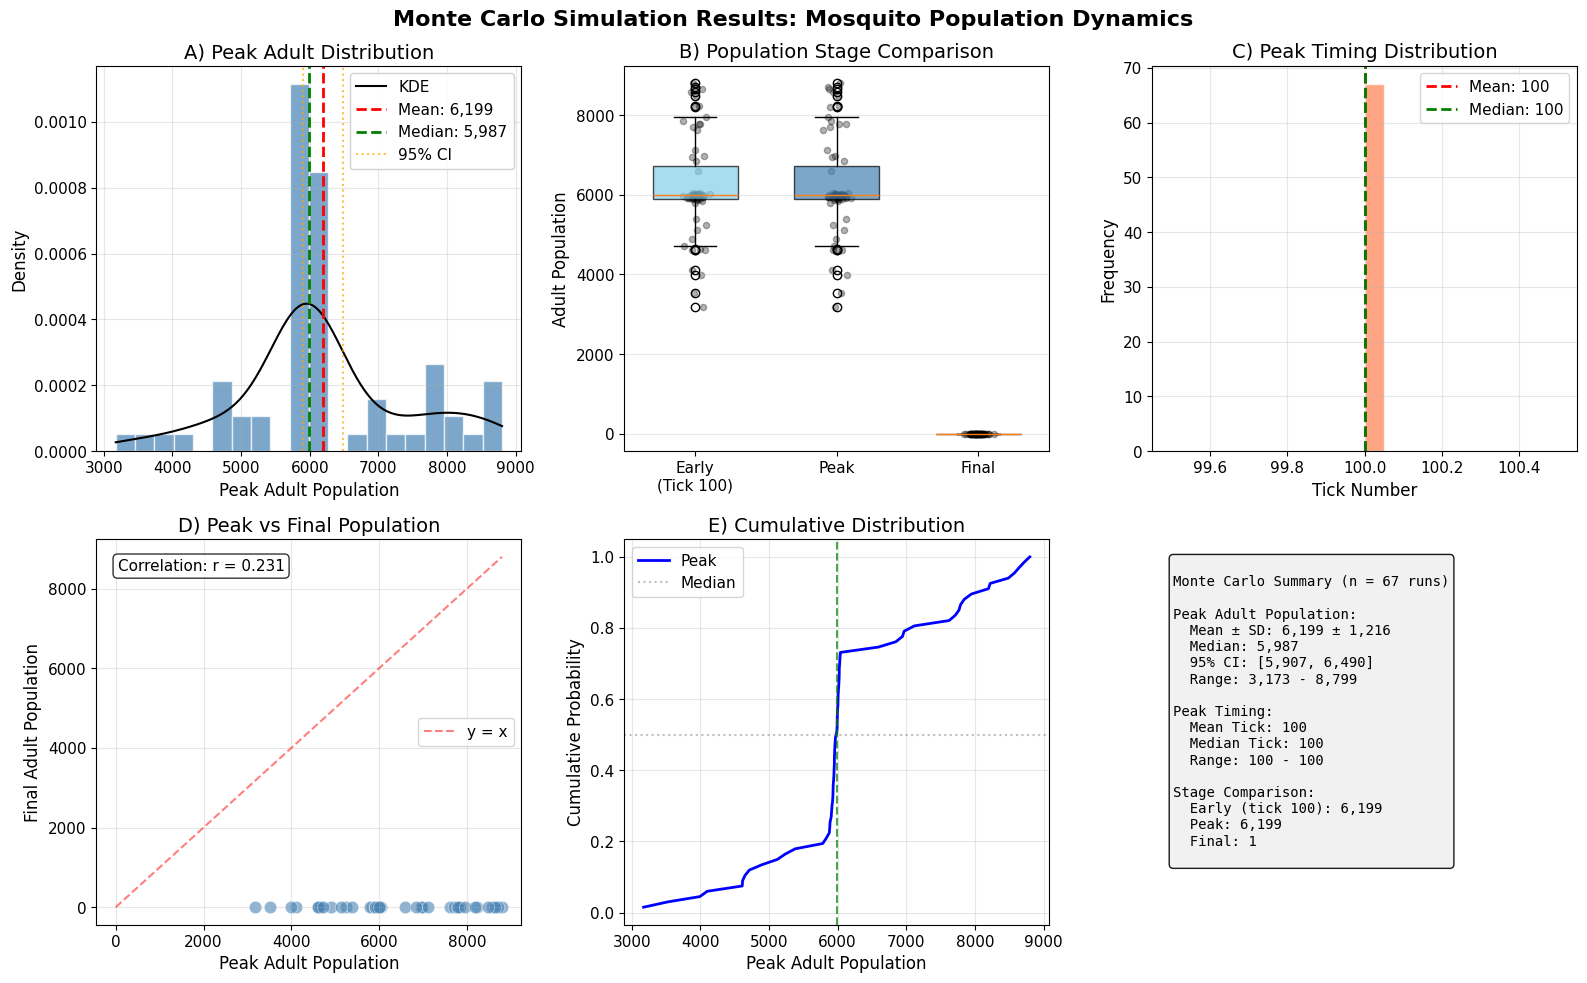


✅ Publication-ready figure saved to: /mnt/monadworld/projects/phd/monte_carlo_results/monte_carlo_publication_figure.png
✅ Publication table saved to: /mnt/monadworld/projects/phd/monte_carlo_results/monte_carlo_publication_table.csv

✅ MONTE CARLO ANALYSIS COMPLETE - PUBLICATION READY

Files saved to: /mnt/monadworld/projects/phd/monte_carlo_results
  - monte_carlo_publication_figure.png (6-panel figure)
  - monte_carlo_publication_table.csv (summary table)
  - monte_carlo_complete_report.txt (full report)


In [10]:
# ======================================================================
# MONTE CARLO - FINAL PUBLICATION-READY SUMMARY
# ======================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

MONTE_CARLO_DIR = "/mnt/monadworld/projects/phd/monte_carlo_results"

# Load the results
df_results = pd.read_csv(os.path.join(MONTE_CARLO_DIR, 'monte_carlo_peak_analysis.csv'))

print("="*70)
print("MONTE CARLO SIMULATION - PUBLICATION SUMMARY")
print("="*70)

# ======================================================================
# KEY STATISTICS
# ======================================================================

peak_mean = df_results['peak_adults'].mean()
peak_std = df_results['peak_adults'].std()
peak_median = df_results['peak_adults'].median()
peak_ci_lower = peak_mean - 1.96 * (peak_std / np.sqrt(len(df_results)))
peak_ci_upper = peak_mean + 1.96 * (peak_std / np.sqrt(len(df_results)))

print(f"\n📊 Peak Adult Population (n={len(df_results)} runs):")
print(f"  Mean ± SD: {peak_mean:,.0f} ± {peak_std:,.0f}")
print(f"  Median: {peak_median:,.0f}")
print(f"  95% CI: [{peak_ci_lower:,.0f}, {peak_ci_upper:,.0f}]")
print(f"  Range: {df_results['peak_adults'].min():,.0f} - {df_results['peak_adults'].max():,.0f}")

# Peak tick
peak_tick_mean = df_results['peak_tick'].mean()
print(f"\n📈 Peak Timing:")
print(f"  Mean peak tick: {peak_tick_mean:.0f}")
print(f"  Median peak tick: {df_results['peak_tick'].median():.0f}")
print(f"  Range: {df_results['peak_tick'].min():.0f} - {df_results['peak_tick'].max():.0f}")

# Early vs Peak vs Final
early_mean = df_results['early_adults'].mean()
final_mean = df_results['final_adults'].mean()
print(f"\n📉 Population Stages:")
print(f"  Early (tick 100): {early_mean:,.0f} adults")
print(f"  Peak: {peak_mean:,.0f} adults")
print(f"  Final: {final_mean:,.0f} adults")

# ======================================================================
# PUBLICATION-READY FIGURE
# ======================================================================

fig = plt.figure(figsize=(16, 10))

# Set style
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['legend.fontsize'] = 11

# 1. Histogram with KDE and confidence intervals
ax1 = plt.subplot(2, 3, 1)
n, bins, patches = ax1.hist(df_results['peak_adults'], bins=20, edgecolor='white', 
                            alpha=0.7, color='steelblue', density=True)
# Add KDE
from scipy.stats import gaussian_kde
kde = gaussian_kde(df_results['peak_adults'])
x_range = np.linspace(df_results['peak_adults'].min(), df_results['peak_adults'].max(), 200)
ax1.plot(x_range, kde(x_range), 'k-', linewidth=1.5, label='KDE')
ax1.axvline(peak_mean, color='red', linestyle='--', linewidth=2, 
           label=f'Mean: {peak_mean:,.0f}')
ax1.axvline(peak_median, color='green', linestyle='--', linewidth=2, 
           label=f'Median: {peak_median:,.0f}')
ax1.axvline(peak_ci_lower, color='orange', linestyle=':', linewidth=1.5, alpha=0.7)
ax1.axvline(peak_ci_upper, color='orange', linestyle=':', linewidth=1.5, alpha=0.7,
           label='95% CI')
ax1.set_xlabel('Peak Adult Population')
ax1.set_ylabel('Density')
ax1.set_title('A) Peak Adult Distribution')
ax1.legend(loc='upper right', framealpha=0.9)
ax1.grid(True, alpha=0.3)

# 2. Box plot with swarm
ax2 = plt.subplot(2, 3, 2)
data_plot = [df_results['early_adults'], df_results['peak_adults'], df_results['final_adults']]
bp = ax2.boxplot(data_plot, labels=['Early\n(Tick 100)', 'Peak', 'Final'], 
                 patch_artist=True, widths=0.6)
colors = ['#87CEEB', '#4682B4', '#2F4F4F']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
# Add swarm plot
for i, data in enumerate(data_plot):
    x = np.random.normal(i+1, 0.04, size=len(data))
    ax2.scatter(x, data, alpha=0.3, s=20, color='black')
ax2.set_ylabel('Adult Population')
ax2.set_title('B) Population Stage Comparison')
ax2.grid(True, alpha=0.3, axis='y')

# 3. Peak tick distribution
ax3 = plt.subplot(2, 3, 3)
ax3.hist(df_results['peak_tick'], bins=20, edgecolor='white', alpha=0.7, color='coral')
ax3.axvline(peak_tick_mean, color='red', linestyle='--', linewidth=2, 
           label=f'Mean: {peak_tick_mean:.0f}')
ax3.axvline(df_results['peak_tick'].median(), color='green', linestyle='--', linewidth=2,
           label=f'Median: {df_results["peak_tick"].median():.0f}')
ax3.set_xlabel('Tick Number')
ax3.set_ylabel('Frequency')
ax3.set_title('C) Peak Timing Distribution')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Peak vs Final scatter
ax4 = plt.subplot(2, 3, 4)
ax4.scatter(df_results['peak_adults'], df_results['final_adults'], 
           alpha=0.6, s=80, c='steelblue', edgecolors='white', linewidth=0.5)
ax4.plot([0, df_results['peak_adults'].max()], [0, df_results['peak_adults'].max()], 
        'r--', alpha=0.5, label='y = x')
# Add correlation
corr = df_results['peak_adults'].corr(df_results['final_adults'])
ax4.text(0.05, 0.95, f'Correlation: r = {corr:.3f}', 
        transform=ax4.transAxes, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax4.set_xlabel('Peak Adult Population')
ax4.set_ylabel('Final Adult Population')
ax4.set_title('D) Peak vs Final Population')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Cumulative distribution
ax5 = plt.subplot(2, 3, 5)
sorted_peak = np.sort(df_results['peak_adults'])
cumulative = np.arange(1, len(sorted_peak) + 1) / len(sorted_peak)
ax5.plot(sorted_peak, cumulative, 'b-', linewidth=2, label='Peak')
ax5.axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='Median')
ax5.axvline(peak_median, color='green', linestyle='--', alpha=0.7)
ax5.set_xlabel('Peak Adult Population')
ax5.set_ylabel('Cumulative Probability')
ax5.set_title('E) Cumulative Distribution')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Summary statistics table
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')
stats_text = f"""
Monte Carlo Summary (n = {len(df_results)} runs)

Peak Adult Population:
  Mean ± SD: {peak_mean:,.0f} ± {peak_std:,.0f}
  Median: {peak_median:,.0f}
  95% CI: [{peak_ci_lower:,.0f}, {peak_ci_upper:,.0f}]
  Range: {df_results['peak_adults'].min():,.0f} - {df_results['peak_adults'].max():,.0f}

Peak Timing:
  Mean Tick: {peak_tick_mean:.0f}
  Median Tick: {df_results['peak_tick'].median():.0f}
  Range: {df_results['peak_tick'].min():.0f} - {df_results['peak_tick'].max():.0f}

Stage Comparison:
  Early (tick 100): {early_mean:,.0f}
  Peak: {peak_mean:,.0f}
  Final: {final_mean:,.0f}
"""
ax6.text(0.05, 0.95, stats_text, transform=ax6.transAxes, 
        verticalalignment='top', fontsize=10, family='monospace',
        bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.9))

plt.suptitle('Monte Carlo Simulation Results: Mosquito Population Dynamics', 
            fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MONTE_CARLO_DIR, 'monte_carlo_publication_figure.png'), 
            dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Publication-ready figure saved to: {os.path.join(MONTE_CARLO_DIR, 'monte_carlo_publication_figure.png')}")

# ======================================================================
# EXPORT FOR PUBLICATION
# ======================================================================

# Create a clean summary table for publication
summary_table = pd.DataFrame({
    'Metric': [
        'Number of Runs',
        'Peak Adult Mean ± SD',
        'Peak Adult Median',
        'Peak Adult 95% CI',
        'Peak Adult Range',
        'Mean Peak Tick',
        'Median Peak Tick',
        'Early Adults (Tick 100)',
        'Final Adults'
    ],
    'Value': [
        f"{len(df_results)}",
        f"{peak_mean:,.0f} ± {peak_std:,.0f}",
        f"{peak_median:,.0f}",
        f"[{peak_ci_lower:,.0f}, {peak_ci_upper:,.0f}]",
        f"{df_results['peak_adults'].min():,.0f} - {df_results['peak_adults'].max():,.0f}",
        f"{peak_tick_mean:.0f}",
        f"{df_results['peak_tick'].median():.0f}",
        f"{early_mean:,.0f}",
        f"{final_mean:,.0f}"
    ]
})

summary_table.to_csv(os.path.join(MONTE_CARLO_DIR, 'monte_carlo_publication_table.csv'), index=False)
print(f"✅ Publication table saved to: {os.path.join(MONTE_CARLO_DIR, 'monte_carlo_publication_table.csv')}")

print("\n" + "="*70)
print("✅ MONTE CARLO ANALYSIS COMPLETE - PUBLICATION READY")
print("="*70)
print(f"\nFiles saved to: {MONTE_CARLO_DIR}")
print(f"  - monte_carlo_publication_figure.png (6-panel figure)")
print(f"  - monte_carlo_publication_table.csv (summary table)")
print(f"  - monte_carlo_complete_report.txt (full report)")